#Section 1

###1.1 Import Libraries

In [ ]:
import os
import re
import time
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from scipy import sparse
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve, brier_score_loss
)

In [ ]:
warnings.filterwarnings('ignore')

###1.2 Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted")

Mounted at /content/drive
Google Drive mounted


###1.3 Set Random Seed

In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"Random seed: {RANDOM_SEED}")

Random seed: 42


###1.4: Create Directory Structure

In [ ]:
BASE_DIR = "/content/drive/MyDrive/Cross-Lingual_Sentiment_Robustness"

DIRS = {
    'base': BASE_DIR,
    'data': f"{BASE_DIR}/data",
    'data_raw': f"{BASE_DIR}/data/raw",
    'data_processed': f"{BASE_DIR}/data/processed",
    'data_folds': f"{BASE_DIR}/data/folds",
    'data_features': f"{BASE_DIR}/data/features",
    'models': f"{BASE_DIR}/models",
    'results': f"{BASE_DIR}/results",
    'results_metrics': f"{BASE_DIR}/results/metrics",
    'results_plots': f"{BASE_DIR}/results/plots",
    'results_calibration': f"{BASE_DIR}/results/calibration",
    'results_oof': f"{BASE_DIR}/results/oof_predictions",
    'results_analysis': f"{BASE_DIR}/results/analysis",
    'logs': f"{BASE_DIR}/logs",
    'src': f"{BASE_DIR}/src"
}

for name, path in DIRS.items():
    os.makedirs(path, exist_ok=True)

print(f"Base: {BASE_DIR}")

Base: /content/drive/MyDrive/Cross-Lingual_Sentiment_Robustness


###1.5: Define Configuration

In [ ]:
CONFIG = {
    'project': {
        'name': 'Cross-Lingual Sentiment Robustness',
        'author': 'DoniyorbekYuldashev',
        'date': '2025-11-01',
        'version': '1.0'
    },
    'dataset': {
        'name': 'amazon_reviews_multi',
        'source': 'Kaggle - mexwell/amazon-reviews-multi',
        'train_lang': 'english',
        'test_lang': 'spanish',
        'sample_size': 25000,
        'task': 'binary_sentiment'
    },
    'cross_validation': {
        'n_folds': 5,
        'strategy': 'stratified',
        'shuffle': True,
        'random_state': RANDOM_SEED
    },
    'text_preprocessing': {
        'lowercase': True,
        'remove_urls': True,
        'remove_special_chars': True,
        'preserve_spanish_accents': True,
        'min_review_length': 10
    },
    'vectorization': {
        'tfidf': {
            'max_features': 10000,
            'ngram_range': (1, 2),
            'min_df': 2,
            'max_df': 0.95,
            'sublinear_tf': True
        },
        'bow': {
            'max_features': 10000,
            'ngram_range': (1, 2),
            'min_df': 2,
            'max_df': 0.95
        }
    },
    'models': {
        'logistic_regression': {
            'C': 1.0,
            'penalty': 'l2',
            'solver': 'lbfgs',
            'max_iter': 1000,
            'random_state': RANDOM_SEED
        },
        'ridge': {
            'alpha': 1.0,
            'solver': 'auto',
            'random_state': RANDOM_SEED
        },
        'svm': {
            'C': 1.0,
            'penalty': 'l2',
            'loss': 'squared_hinge',
            'max_iter': 1000,
            'random_state': RANDOM_SEED
        },
        'sgd': {
            'loss': 'log_loss',
            'penalty': 'l2',
            'alpha': 0.0001,
            'max_iter': 1000,
            'random_state': RANDOM_SEED
        },
        'naive_bayes': {
            'alpha': 1.0
        },
        'perceptron': {
            'alpha': [0.0001, 0.001, 0.01, 0.1],
            'penalty': ['l2', 'l1', 'elasticnet'],
            'max_iter': [1000, 2000],
            'random_state': RANDOM_SEED
        },
        'mlp': {
            'hidden_layer_sizes': [(100,), (100, 50), (200,), (200, 100)],
            'activation': ['relu', 'tanh'],
            'alpha': [0.0001, 0.001, 0.01],
            'learning_rate': ['constant', 'adaptive'],
            'max_iter': [500],
            'early_stopping': True,
            'validation_fraction': 0.1,
            'random_state': RANDOM_SEED
        }
    },

    'calibration': {
        'methods': ['platt', 'isotonic'],
        'platt': {
            'method': 'sigmoid',
            'cv': 'prefit'
        },
        'isotonic': {
            'method': 'isotonic',
            'cv': 'prefit'
        },
        'n_bins': 10
    },
    'evaluation': {
        'metrics': ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'brier', 'ece'],
        'average': 'binary',
        'save_predictions': True,
        'save_probabilities': True,
        'save_oof': True
    },
    'ensemble': {
        'voting_types': ['hard', 'soft'],
        'weights': None
    }
}

config_path = f"{DIRS['base']}/config.json"
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)

print("Configuration saved")

Configuration saved


###1.6: Define Utility Functions

In [ ]:
def save_csv(dataframe, filepath, description=""):
    dataframe.to_csv(filepath, index=False)

def save_json(data, filepath, description=""):
    with open(filepath, 'w') as f:
        json.dump(data, f, indent=2)

def save_pickle(obj, filepath, description=""):
    with open(filepath, 'wb') as f:
        pickle.dump(obj, f)

def load_pickle(filepath, description=""):
    with open(filepath, 'rb') as f:
        obj = pickle.load(f)
    return obj

def format_time(seconds):
    if seconds < 60:
        return f"{seconds:.1f}s"
    elif seconds < 3600:
        return f"{seconds/60:.1f}m"
    else:
        return f"{seconds/3600:.1f}h"

print("Utility functions defined")

Utility functions defined


#Section 2 - Data Loading & Exploration

###2.1: Install KaggleHub and Download Dataset

In [ ]:
!pip install -q kagglehub

import kagglehub
import gc

path = kagglehub.dataset_download("mexwell/amazon-reviews-multi")

print(f"Path: {path}")

100%|██████████| 131M/131M [00:00<00:00, 145MB/s]

Extracting files...


Path: /root/.cache/kagglehub/datasets/mexwell/amazon-reviews-multi/versions/1


###2.2: Explore Dataset Files

In [ ]:
files = []
for root, dirs, filenames in os.walk(path):
    for f in filenames:
        files.append(os.path.join(root, f))

print(f"\nAll files ({len(files)}):")
for f in files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"  - {os.path.basename(f)} ({size_mb:.1f} MB)")

csv_files = [f for f in files if '.csv' in f.lower()]

print(f"\nCSV files: {len(csv_files)}")
for f in csv_files:
    print(f"  - {os.path.basename(f)}")


All files (3):
  - train.csv (330.2 MB)
  - validation.csv (8.2 MB)
  - test.csv (8.2 MB)

CSV files: 3
  - train.csv
  - validation.csv
  - test.csv


###2.3: Load English and Spanish Data

In [ ]:
train_file = [f for f in csv_files if 'train' in f.lower()][0]

def load_language_data(lang_code, target_size=60000, seed_offset=0):
    chunks = []
    for i, chunk in enumerate(pd.read_csv(train_file, chunksize=10000)):
        lang_chunk = chunk[chunk['language'] == lang_code].copy()
        if len(lang_chunk) > 0:
            chunks.append(lang_chunk.sample(frac=0.3, random_state=RANDOM_SEED + i + seed_offset))
        if chunks and len(pd.concat(chunks)) >= target_size:
            break
    return pd.concat(chunks, ignore_index=True)

english_data = load_language_data('en', seed_offset=0)
spanish_data = load_language_data('es', seed_offset=100)

gc.collect()

print(f"English: {len(english_data):,}")
print(f"Spanish: {len(spanish_data):,}")

English: 60,000
Spanish: 60,000


###2.5: Identify Columns

In [ ]:
# Rename columns
english_data = english_data.rename(columns={'review_body': 'text', 'stars': 'rating'})
spanish_data = spanish_data.rename(columns={'review_body': 'text', 'stars': 'rating'})

print(f"EN distribution:\n{english_data['rating'].value_counts().sort_index()}")
print(f"\nES distribution:\n{spanish_data['rating'].value_counts().sort_index()}")

EN distribution:
rating
1    12000
2    12000
3    12000
4    12000
5    12000
Name: count, dtype: int64

ES distribution:
rating
1    12000
2    12000
3    12000
4    12000
5    12000
Name: count, dtype: int64


###2.6: Create Binary Labels

In [ ]:
# Filter and create binary labels
english_binary = english_data[['text', 'rating']].dropna()
english_binary = english_binary[english_binary['rating'].isin([1, 2, 4, 5])]
english_binary['label'] = (english_binary['rating'] > 3).astype(int)
english_binary = english_binary[['text', 'label']]

spanish_binary = spanish_data[['text', 'rating']].dropna()
spanish_binary = spanish_binary[spanish_binary['rating'].isin([1, 2, 4, 5])]
spanish_binary['label'] = (spanish_binary['rating'] > 3).astype(int)
spanish_binary = spanish_binary[['text', 'label']]

print(f"EN: {len(english_binary):,}, ES: {len(spanish_binary):,}")

EN: 48,000, ES: 48,000


###2.7: Stratified Sampling

In [ ]:
n = CONFIG['dataset']['sample_size'] // 2

english_sample = pd.concat([
    english_binary[english_binary['label']==0].sample(n=n, random_state=RANDOM_SEED),
    english_binary[english_binary['label']==1].sample(n=n, random_state=RANDOM_SEED)
]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

spanish_sample = pd.concat([
    spanish_binary[spanish_binary['label']==0].sample(n=n, random_state=RANDOM_SEED+1),
    spanish_binary[spanish_binary['label']==1].sample(n=n, random_state=RANDOM_SEED+1)
]).sample(frac=1, random_state=RANDOM_SEED+1).reset_index(drop=True)

del english_binary, spanish_binary
gc.collect()

print(f"EN: {len(english_sample):,}, ES: {len(spanish_sample):,}")



EN: 25,000, ES: 25,000


###2.8: Quality Checks

In [ ]:
print("Cleaning text data...")

# Convert to string and calculate length
for df in [english_sample, spanish_sample]:
    df['text'] = df['text'].astype(str)
    df['text_length'] = df['text'].str.len()

print(f"Text length - EN: {english_sample['text_length'].mean():.0f}, ES: {spanish_sample['text_length'].mean():.0f}")

# Filter short texts and remove duplicates
min_length = CONFIG['text_preprocessing']['min_review_length']
english_sample = english_sample[english_sample['text_length'] >= min_length].drop_duplicates(subset=['text']).reset_index(drop=True)
spanish_sample = spanish_sample[spanish_sample['text_length'] >= min_length].drop_duplicates(subset=['text']).reset_index(drop=True)

print(f"After cleaning - EN: {len(english_sample):,}, ES: {len(spanish_sample):,}")

Cleaning text data...
Text length - EN: 175, ES: 150
After cleaning - EN: 24,985, ES: 24,905


###2.9: Add IDs and Display Samples

In [ ]:
# Add IDs
english_sample.insert(0, 'tweet_id', range(len(english_sample)))
spanish_sample.insert(0, 'tweet_id', range(len(spanish_sample)))

# Display sample reviews
print("Sample reviews:")
print(f"  EN Negative: {english_sample[english_sample['label']==0].iloc[0]['text'][:100]}...")
print(f"  EN Positive: {english_sample[english_sample['label']==1].iloc[0]['text'][:100]}...")
print(f"  ES Negative: {spanish_sample[spanish_sample['label']==0].iloc[0]['text'][:100]}...")
print(f"  ES Positive: {spanish_sample[spanish_sample['label']==1].iloc[0]['text'][:100]}...")

Sample reviews:
  EN Negative: This product is not worth the money. 3 months later the plastic cover is already cracked. Initially ...
  EN Positive: This gets you walking in an upright position. Makes you walk correctly...
  ES Negative: Llevo un mes esperando a este producto. Lleva 10 días de retraso y no consigo saber dónde está el pa...
  ES Positive: Estupendo recipiente para guardar cualquier líquido que necesite dosificador. Genial el precio respe...


###2.10: Save Processed Data

In [ ]:
# Save processed data
english_final = english_sample[['tweet_id', 'text', 'label']].copy()
spanish_final = spanish_sample[['tweet_id', 'text', 'label']].copy()

save_csv(english_final, f"{DIRS['data_processed']}/english_processed.csv")
save_csv(spanish_final, f"{DIRS['data_processed']}/spanish_processed.csv")

print(f"Saved: english_processed.csv, spanish_processed.csv")

Saved: english_processed.csv, spanish_processed.csv


###2.11: Create Summary

In [ ]:
summary = {
    'english': {'total': len(english_final), 'neg': int((english_final['label']==0).sum()), 'pos': int((english_final['label']==1).sum())},
    'spanish': {'total': len(spanish_final), 'neg': int((spanish_final['label']==0).sum()), 'pos': int((spanish_final['label']==1).sum())}
}

save_json(summary, f"{DIRS['data']}/data_summary.json")
print(f"EN: {summary['english']['total']:,}, ES: {summary['spanish']['total']:,}")

EN: 24,985, ES: 24,905


###2.12: Section 2 Complete

In [ ]:
print(f"\nSection 2 Complete")
print(f"EN: {len(english_final):,}, ES: {len(spanish_final):,}")
print(f"Task: Binary sentiment classification\n")

del english_sample, spanish_sample
gc.collect()


Section 2 Complete
EN: 24,985, ES: 24,905
Task: Binary sentiment classification



33

##Section 3: Text Preprocessing & Fold Creation

###3.1: Section Header and Load Processed Data

In [ ]:
english_data = pd.read_csv(f"{DIRS['data_processed']}/english_processed.csv")
spanish_data = pd.read_csv(f"{DIRS['data_processed']}/spanish_processed.csv")

print(f"Data loaded:")
print(f"English: {len(english_data):,} reviews")
print(f"Spanish: {len(spanish_data):,} reviews")

Data loaded:
English: 24,985 reviews
Spanish: 24,905 reviews


###3.2: Define Text Cleaning Function

In [ ]:
def clean_text(text, preserve_accents=False):
    """Clean and normalize text."""
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Remove URLs

    if preserve_accents:
        text = re.sub(r'[^a-záéíóúñüA-ZÁÉÍÓÚÑÜ0-9\s.,!?¡¿\-]', ' ', text)
    else:
        text = re.sub(r'[^a-zA-Z0-9\s.,!?\-]', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    return text

print("Text cleaning function ready")

Text cleaning function ready


###3.3: Apply Preprocessing to English and Spanish Data

In [ ]:
english_data['text_clean'] = english_data['text'].apply(clean_text)
spanish_data['text_clean'] = spanish_data['text'].apply(lambda x: clean_text(x, preserve_accents=True))

for name, df in [('english', english_data), ('spanish', spanish_data)]:
    before = len(df)
    df = df[df['text_clean'].str.len() > 0].reset_index(drop=True)
    if name == 'english':
        english_data = df
    else:
        spanish_data = df
    print(f"{name.capitalize()}: {len(df):,}")

English: 24,985
Spanish: 24,905


###3.5: Display Sample Preprocessed Reviews

In [ ]:
print("Preprocessing examples:")

for lang, df in [('EN', english_data), ('ES', spanish_data)]:
    for label in [0, 1]:
        idx = df[df['label']==label].index[0]
        sentiment = 'Negative' if label == 0 else 'Positive'
        print(f"\n{lang} {sentiment}:")
        print(f"  Original: {df.loc[idx, 'text'][:100]}...")
        print(f"  Cleaned:  {df.loc[idx, 'text_clean'][:100]}...")

Preprocessing examples:

EN Negative:
  Original: This product is not worth the money. 3 months later the plastic cover is already cracked. Initially ...
  Cleaned:  this product is not worth the money. 3 months later the plastic cover is already cracked. initially ...

EN Positive:
  Original: This gets you walking in an upright position. Makes you walk correctly...
  Cleaned:  this gets you walking in an upright position. makes you walk correctly...

ES Negative:
  Original: Llevo un mes esperando a este producto. Lleva 10 días de retraso y no consigo saber dónde está el pa...
  Cleaned:  llevo un mes esperando a este producto. lleva 10 días de retraso y no consigo saber dónde está el pa...

ES Positive:
  Original: Estupendo recipiente para guardar cualquier líquido que necesite dosificador. Genial el precio respe...
  Cleaned:  estupendo recipiente para guardar cualquier líquido que necesite dosificador. genial el precio respe...


###3.6: Create Stratified K-Folds

In [ ]:
print(f"Creating {CONFIG['cross_validation']['n_folds']} stratified folds...")

skf = StratifiedKFold(
    n_splits=CONFIG['cross_validation']['n_folds'],
    shuffle=CONFIG['cross_validation']['shuffle'],
    random_state=CONFIG['cross_validation']['random_state']
)

X = english_data['text_clean'].values
y = english_data['label'].values

folds_info = []
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    train_labels, val_labels = y[train_idx], y[val_idx]

    fold_data = {
        'fold': fold_idx,
        'train_size': len(train_idx),
        'val_size': len(val_idx),
        'train_negative': int((train_labels == 0).sum()),
        'train_positive': int((train_labels == 1).sum()),
        'val_negative': int((val_labels == 0).sum()),
        'val_positive': int((val_labels == 1).sum())
    }
    folds_info.append(fold_data)

    print(f"  Fold {fold_idx}: Train={len(train_idx):,} (Neg:{fold_data['train_negative']:,}, Pos:{fold_data['train_positive']:,}), Val={len(val_idx):,}")

print(f"{len(folds_info)} folds created")

Creating 5 stratified folds...
  Fold 1: Train=19,988 (Neg:9,993, Pos:9,995), Val=4,997
  Fold 2: Train=19,988 (Neg:9,993, Pos:9,995), Val=4,997
  Fold 3: Train=19,988 (Neg:9,994, Pos:9,994), Val=4,997
  Fold 4: Train=19,988 (Neg:9,994, Pos:9,994), Val=4,997
  Fold 5: Train=19,988 (Neg:9,994, Pos:9,994), Val=4,997
5 folds created


###3.7: Save Fold Indices

In [ ]:
n_folds = CONFIG['cross_validation']['n_folds']

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    fold_dict = {
        'fold': fold_idx,
        'train_indices': train_idx.tolist(),
        'val_indices': val_idx.tolist(),
        'train_size': len(train_idx),
        'val_size': len(val_idx)
    }
    save_json(fold_dict, f"{DIRS['data_folds']}/fold_{fold_idx}_indices.json")

print(f"Saved {n_folds} fold files")

Saved 5 fold files


###3.8: Save Preprocessed Data

In [ ]:
# Save preprocessed data
english_data[['tweet_id', 'text', 'text_clean', 'label']].to_csv(f"{DIRS['data_processed']}/english_preprocessed.csv", index=False)
spanish_data[['tweet_id', 'text', 'text_clean', 'label']].to_csv(f"{DIRS['data_processed']}/spanish_preprocessed.csv", index=False)

print(f"Preprocessed data saved")

Preprocessed data saved


###3.9: Create Preprocessing Summary

In [ ]:
preprocessing_summary = {
    'date': datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S'),
    'user': 'DoniyorbekYuldashev',
    'english': {
        'total': len(english_data),
        'negative': int((english_data['label']==0).sum()),
        'positive': int((english_data['label']==1).sum())
    },
    'spanish': {
        'total': len(spanish_data),
        'negative': int((spanish_data['label']==0).sum()),
        'positive': int((spanish_data['label']==1).sum())
    },
    'cross_validation': {
        'n_folds': CONFIG['cross_validation']['n_folds'],
        'folds_info': folds_info
    }
}

save_json(preprocessing_summary, f"{DIRS['data']}/preprocessing_summary.json")

print(f"Preprocessing summary saved")

Preprocessing summary saved


###3.10: Create Visualization of Fold Distribution

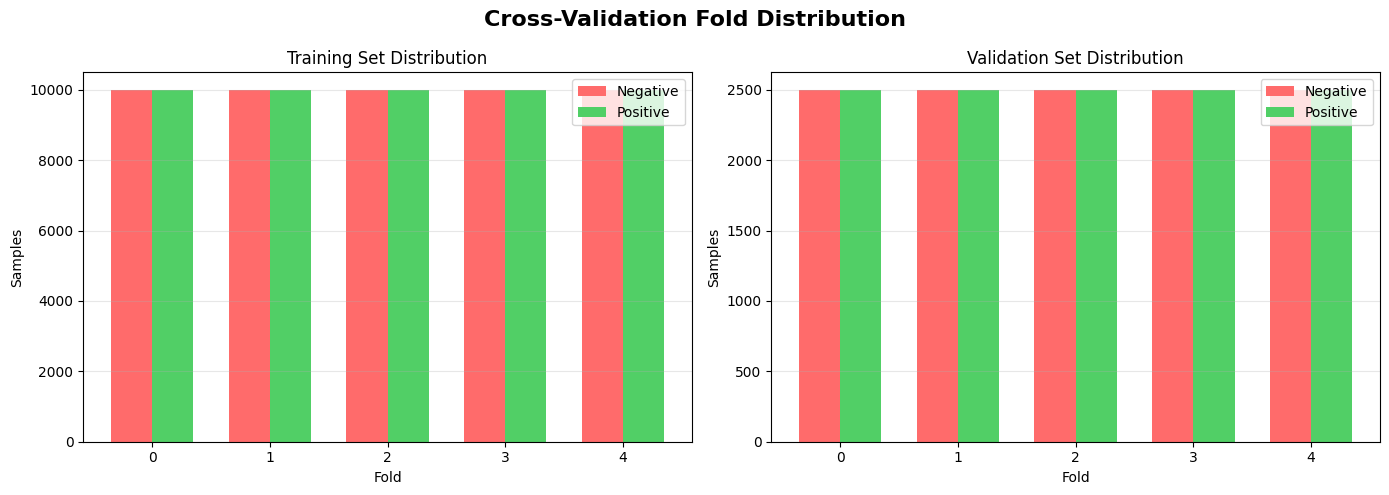

Fold distribution plot saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cross-Validation Fold Distribution', fontsize=16, fontweight='bold')

folds = [f['fold'] for f in folds_info]
x = np.arange(len(folds))
width = 0.35

# Train set
train_neg = [f['train_negative'] for f in folds_info]
train_pos = [f['train_positive'] for f in folds_info]
axes[0].bar(x - width/2, train_neg, width, label='Negative', color='#ff6b6b')
axes[0].bar(x + width/2, train_pos, width, label='Positive', color='#51cf66')
axes[0].set_title('Training Set Distribution')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Samples')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Validation set
val_neg = [f['val_negative'] for f in folds_info]
val_pos = [f['val_positive'] for f in folds_info]
axes[1].bar(x - width/2, val_neg, width, label='Negative', color='#ff6b6b')
axes[1].bar(x + width/2, val_pos, width, label='Positive', color='#51cf66')
axes[1].set_title('Validation Set Distribution')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Samples')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DIRS['results_plots']}/fold_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

print("Fold distribution plot saved")

###3.11: Section 3 Complete

In [ ]:
print(f"\nEnglish preprocessed: {len(english_data):,} reviews")
print(f"Spanish preprocessed: {len(spanish_data):,} reviews")
print(f"K-folds created: {n_folds}")
print(f"Average fold size: ~{len(english_data) // n_folds:,} reviews")

print("\nFiles created:")
print(f"english_preprocessed.csv")
print(f"spanish_preprocessed.csv")
print(f"{n_folds} fold index files")
print(f"preprocessing_summary.json")
print(f"fold_distribution.png")


English preprocessed: 24,985 reviews
Spanish preprocessed: 24,905 reviews
K-folds created: 5
Average fold size: ~4,997 reviews

Files created:
english_preprocessed.csv
spanish_preprocessed.csv
5 fold index files
preprocessing_summary.json
fold_distribution.png


#Section 4: Feature Extraction (TF-IDF & BoW)

###4.1: Section Header and Load Preprocessed Data

In [ ]:
english_data = pd.read_csv(f"{DIRS['data_processed']}/english_preprocessed.csv")
spanish_data = pd.read_csv(f"{DIRS['data_processed']}/spanish_preprocessed.csv")

print(f"Data loaded:")
print(f"English: {len(english_data):,} reviews")
print(f"Spanish: {len(spanish_data):,} reviews")

Data loaded:
English: 24,985 reviews
Spanish: 24,905 reviews


###4.2: Initialize TF-IDF Vectorizer

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=CONFIG['vectorization']['tfidf']['max_features'],
    ngram_range=tuple(CONFIG['vectorization']['tfidf']['ngram_range']),
    min_df=CONFIG['vectorization']['tfidf']['min_df'],
    max_df=CONFIG['vectorization']['tfidf']['max_df'],
    sublinear_tf=CONFIG['vectorization']['tfidf']['sublinear_tf'],
    strip_accents=None
)

print(f"TF-IDF: max_features={CONFIG['vectorization']['tfidf']['max_features']:,}, ngrams={CONFIG['vectorization']['tfidf']['ngram_range']}")

TF-IDF: max_features=10,000, ngrams=(1, 2)


###4.3: Fit TF-IDF on English Training Data

In [ ]:
print("Fitting TF-IDF vectorizer...")

X_train_text = english_data['text_clean'].values

fit_start = time.time()
tfidf_vectorizer.fit(X_train_text)
fit_time = time.time() - fit_start

print(f"Fitted in {fit_time:.2f}s - Vocabulary: {len(tfidf_vectorizer.vocabulary_):,} terms")

Fitting TF-IDF vectorizer...
Fitted in 8.41s - Vocabulary: 10,000 terms


###4.4: Transform English Data with TF-IDF

In [ ]:
transform_start = time.time()
X_english_tfidf = tfidf_vectorizer.transform(X_train_text)
transform_time = time.time() - transform_start

print(f"English transformed in {transform_time:.2f}s - Shape: {X_english_tfidf.shape}, Sparsity: {(1 - X_english_tfidf.nnz / (X_english_tfidf.shape[0] * X_english_tfidf.shape[1])) * 100:.2f}%")

English transformed in 4.26s - Shape: (24985, 10000), Sparsity: 99.63%


###4.5: Transform Spanish Data with TF-IDF

In [ ]:
X_spanish_text = spanish_data['text_clean'].values

transform_start = time.time()
X_spanish_tfidf = tfidf_vectorizer.transform(X_spanish_text)
transform_time = time.time() - transform_start

print(f"Spanish transformed in {transform_time:.2f}s - Shape: {X_spanish_tfidf.shape}, Sparsity: {(1 - X_spanish_tfidf.nnz / (X_spanish_tfidf.shape[0] * X_spanish_tfidf.shape[1])) * 100:.2f}%")
print(f"Cross-lingual: {X_spanish_tfidf.nnz / X_spanish_tfidf.shape[0]:.1f} terms/review (EN: {X_english_tfidf.nnz / X_english_tfidf.shape[0]:.1f})")

Spanish transformed in 2.25s - Shape: (24905, 10000), Sparsity: 99.98%
Cross-lingual: 1.7 terms/review (EN: 37.0)


###4.6: Initialize BoW Vectorizer

In [ ]:
bow_config = CONFIG['vectorization']['bow']

bow_vectorizer = CountVectorizer(
    max_features=bow_config['max_features'],
    ngram_range=tuple(bow_config['ngram_range']),
    min_df=bow_config['min_df'],
    max_df=bow_config['max_df'],
    strip_accents=None
)

print(f"BoW configuration:")
print(f"Max features: {bow_config['max_features']:,}")
print(f"N-gram range: {bow_config['ngram_range']}")
print(f"Min document frequency: {bow_config['min_df']}")
print(f"Max document frequency: {bow_config['max_df']}")

BoW configuration:
Max features: 10,000
N-gram range: (1, 2)
Min document frequency: 2
Max document frequency: 0.95


###4.7: Fit BoW on English Training Data

In [ ]:
bow_vectorizer.fit(X_train_text)

print(f"Vocabulary size: {len(bow_vectorizer.vocabulary_):,} terms")
print(f"Feature names (first 10): {bow_vectorizer.get_feature_names_out()[:10].tolist()}")
print(f"Feature names (last 10): {bow_vectorizer.get_feature_names_out()[-10:].tolist()}")

Vocabulary size: 10,000 terms
Feature names (first 10): ['00', '10', '10 and', '10 minutes', '10 months', '100', '11', '12', '13', '14']
Feature names (last 10): ['yourself', 'youtube', 'yr', 'yr old', 'zero', 'zero stars', 'zip', 'zipper', 'zipper broke', 'zippers']


###4.8: Transform English Data with BoW

In [ ]:
X_english_bow = bow_vectorizer.transform(X_train_text)

print(f"English transformed in {transform_time:.2f}s")
print(f"Shape: {X_english_bow.shape}")
print(f"Sparsity: {(1 - X_english_bow.nnz / (X_english_bow.shape[0] * X_english_bow.shape[1])) * 100:.2f}%")
print(f"Memory: {X_english_bow.data.nbytes / (1024*1024):.2f} MB")

English transformed in 2.25s
Shape: (24985, 10000)
Sparsity: 99.63%
Memory: 7.05 MB


###4.9: Transform Spanish Data with BoW

In [ ]:
X_spanish_bow = bow_vectorizer.transform(X_spanish_text)

print(f"Shape: {X_spanish_bow.shape}")
print(f"Sparsity: {(1 - X_spanish_bow.nnz / (X_spanish_bow.shape[0] * X_spanish_bow.shape[1])) * 100:.2f}%")
print(f"Memory: {X_spanish_bow.data.nbytes / (1024*1024):.2f} MB")

print(f"\nCross-lingual transfer:")
print(f"English vocabulary matched: {X_spanish_bow.nnz / X_spanish_bow.shape[0]:.1f} terms/review")
print(f"Out-of-vocabulary impact: {((X_english_bow.nnz / X_english_bow.shape[0]) - (X_spanish_bow.nnz / X_spanish_bow.shape[0])):.1f} terms/review difference")

Shape: (24905, 10000)
Sparsity: 99.98%
Memory: 0.33 MB

Cross-lingual transfer:
English vocabulary matched: 1.7 terms/review
Out-of-vocabulary impact: 35.3 terms/review difference


###4.10: Save Vectorizers

In [ ]:
import pickle

tfidf_path = f"{DIRS['models']}/tfidf_vectorizer.pkl"
bow_path = f"{DIRS['models']}/bow_vectorizer.pkl"

with open(tfidf_path, 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

with open(bow_path, 'wb') as f:
    pickle.dump(bow_vectorizer, f)

print(f"Vectorizers saved:")
print(f" {tfidf_path}")
print(f" {bow_path}")

print(f"\nFile sizes:")
print(f"TF-IDF: {os.path.getsize(tfidf_path) / (1024*1024):.2f} MB")
print(f"BoW: {os.path.getsize(bow_path) / (1024*1024):.2f} MB")

Vectorizers saved:
 /content/drive/MyDrive/Cross-Lingual_Sentiment_Robustness/models/tfidf_vectorizer.pkl
 /content/drive/MyDrive/Cross-Lingual_Sentiment_Robustness/models/bow_vectorizer.pkl

File sizes:
TF-IDF: 0.36 MB
BoW: 0.29 MB


###4.11: Save Feature Matrices

In [ ]:
from scipy import sparse

# Save matrices
sparse.save_npz(f"{DIRS['data_processed']}/X_english_tfidf.npz", X_english_tfidf)
sparse.save_npz(f"{DIRS['data_processed']}/X_spanish_tfidf.npz", X_spanish_tfidf)
sparse.save_npz(f"{DIRS['data_processed']}/X_english_bow.npz", X_english_bow)
sparse.save_npz(f"{DIRS['data_processed']}/X_spanish_bow.npz", X_spanish_bow)

print("Feature matrices saved (TF-IDF + BoW for EN/ES)")

Feature matrices saved (TF-IDF + BoW for EN/ES)


###4.12: Analyze Top Features

In [ ]:
def get_top_features(vectorizer, top_n=20):
    return vectorizer.get_feature_names_out()[:top_n].tolist()

print("Top 20 TF-IDF features:", get_top_features(tfidf_vectorizer, 20))
print("Top 20 BoW features:", get_top_features(bow_vectorizer, 20))

Top 20 TF-IDF features: ['00', '10', '10 and', '10 minutes', '10 months', '100', '11', '12', '13', '14', '15', '15 minutes', '150', '16', '17', '18', '19', '1st', '20', '20 minutes']
Top 20 BoW features: ['00', '10', '10 and', '10 minutes', '10 months', '100', '11', '12', '13', '14', '15', '15 minutes', '150', '16', '17', '18', '19', '1st', '20', '20 minutes']


###4.13: Create Feature Extraction Summary

In [ ]:
feature_summary = {
    'tfidf': {
        'vocab_size': len(tfidf_vectorizer.vocabulary_),
        'en_shape': X_english_tfidf.shape,
        'es_shape': X_spanish_tfidf.shape
    },
    'bow': {
        'vocab_size': len(bow_vectorizer.vocabulary_),
        'en_shape': X_english_bow.shape,
        'es_shape': X_spanish_bow.shape
    }
}

save_json(feature_summary, f"{DIRS['data']}/feature_extraction_summary.json")
print("Summary saved")

Summary saved


###4.14: Create Feature Distribution Visualization

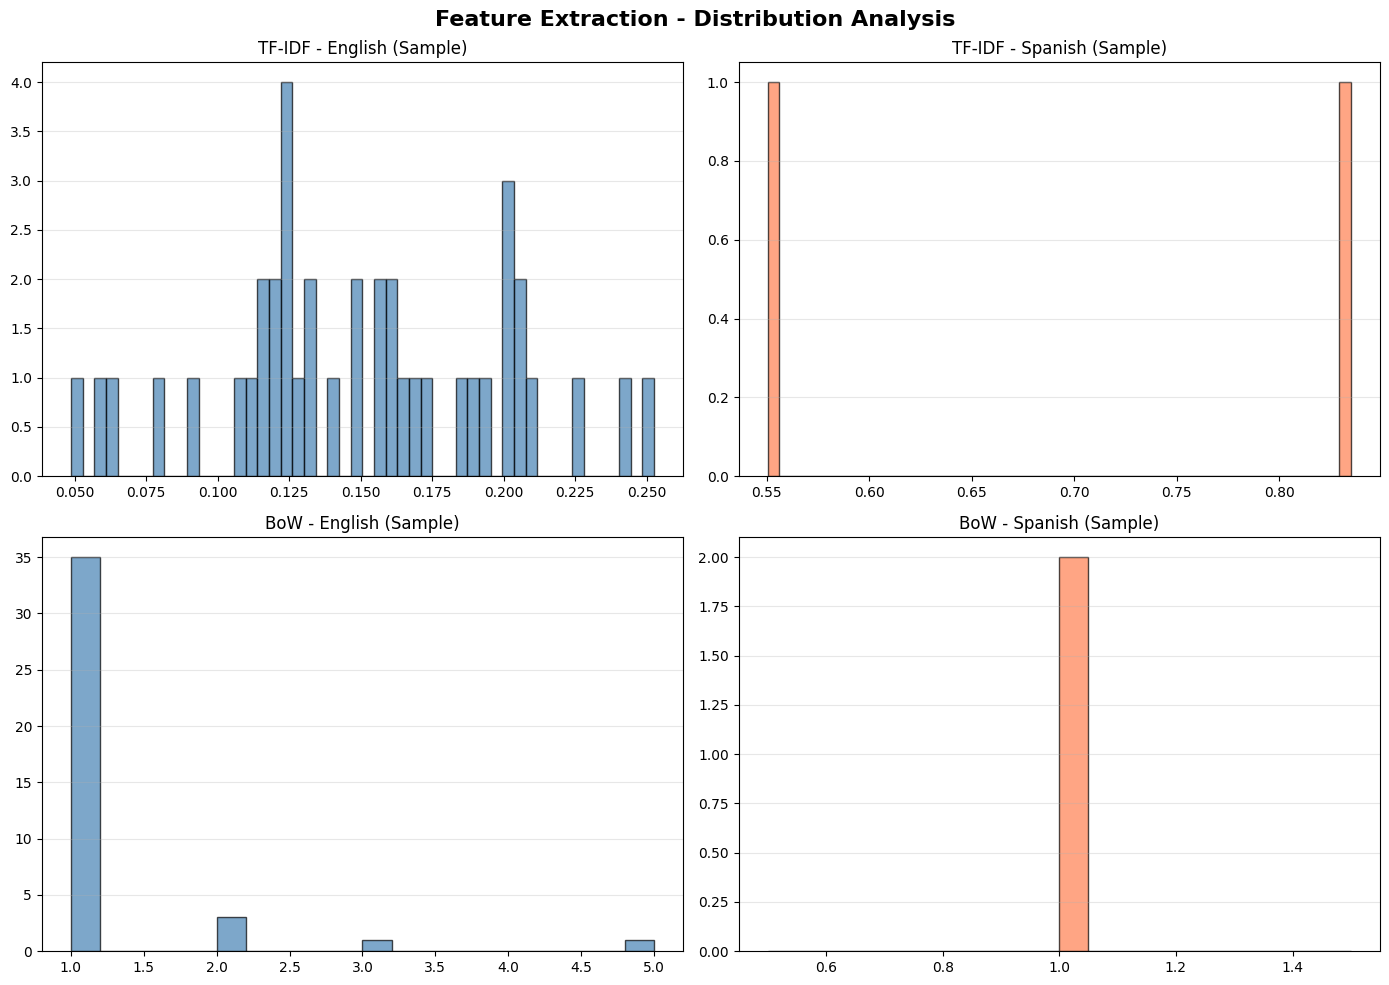

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Extraction - Distribution Analysis', fontsize=16, fontweight='bold')

for (matrix, title, color, bins), ax in zip([
    (X_english_tfidf, 'TF-IDF - English', 'steelblue', 50),
    (X_spanish_tfidf, 'TF-IDF - Spanish', 'coral', 50),
    (X_english_bow, 'BoW - English', 'steelblue', 20),
    (X_spanish_bow, 'BoW - Spanish', 'coral', 20)
], axes.flat):
    dense = matrix.toarray()[0]
    ax.hist(dense[dense > 0], bins=bins, color=color, alpha=0.7, edgecolor='black')
    ax.set_title(title + ' (Sample)')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DIRS['results_plots']}/feature_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

###4.15: Section 4 Complete

In [ ]:
print(f"\nTF-IDF vocabulary: {len(tfidf_vectorizer.vocabulary_):,} terms")
print(f"BoW vocabulary: {len(bow_vectorizer.vocabulary_):,} terms")
print(f"English features: {X_english_tfidf.shape[1]:,} dimensions")
print(f"Spanish features: {X_spanish_tfidf.shape[1]:,} dimensions")

print("\nFiles created: tfidf_vectorizer.pkl, bow_vectorizer.pkl, X_english_tfidf.npz, X_spanish_tfidf.npz, X_english_bow.npz, X_spanish_bow.npz, feature_extraction_summary.json, feature_distributions.png")


TF-IDF vocabulary: 10,000 terms
BoW vocabulary: 10,000 terms
English features: 10,000 dimensions
Spanish features: 10,000 dimensions

Files created: tfidf_vectorizer.pkl, bow_vectorizer.pkl, X_english_tfidf.npz, X_spanish_tfidf.npz, X_english_bow.npz, X_spanish_bow.npz, feature_extraction_summary.json, feature_distributions.png


#Section 5: Model Training & Cross-Validation

###5.1: Section Header and Load Data

In [ ]:
english_data = pd.read_csv(f"{DIRS['data_processed']}/english_preprocessed.csv")
y_english = english_data['label'].values

from scipy import sparse
X_english_tfidf = sparse.load_npz(f"{DIRS['data_processed']}/X_english_tfidf.npz")
X_english_bow = sparse.load_npz(f"{DIRS['data_processed']}/X_english_bow.npz")

print(f"Data loaded:")
print(f"English samples: {len(y_english):,}")
print(f"TF-IDF features: {X_english_tfidf.shape[1]:,}")
print(f"BoW features: {X_english_bow.shape[1]:,}")

Data loaded:
English samples: 24,985
TF-IDF features: 10,000
BoW features: 10,000


###5.2: Load Fold Indices

In [ ]:
import json

n_folds = CONFIG['cross_validation']['n_folds']
folds = []

for fold_idx in range(1, n_folds + 1):
    fold_path = f"{DIRS['data_folds']}/fold_{fold_idx}_indices.json"
    with open(fold_path, 'r') as f:
        fold_data = json.load(f)
        folds.append({
            'fold': fold_idx,
            'train_idx': np.array(fold_data['train_indices']),
            'val_idx': np.array(fold_data['val_indices'])
        })

print(f"Loaded {n_folds} folds:")
for fold in folds:
    print(f"  Fold {fold['fold']}: Train={len(fold['train_idx']):,}, Val={len(fold['val_idx']):,}")

Loaded 5 folds:
  Fold 1: Train=19,988, Val=4,997
  Fold 2: Train=19,988, Val=4,997
  Fold 3: Train=19,988, Val=4,997
  Fold 4: Train=19,988, Val=4,997
  Fold 5: Train=19,988, Val=4,997


###5.3: Define Model Configurations

In [ ]:
models_config = {
    'logistic_regression': {
        'name': 'Logistic Regression',
        'model': LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_SEED, n_jobs=-1),
        'needs_calibration': False
    },
    'ridge': {
        'name': 'Ridge Classifier',
        'model': RidgeClassifier(alpha=1.0, random_state=RANDOM_SEED),
        'needs_calibration': True
    },
    'svm': {
        'name': 'Linear SVM',
        'model': LinearSVC(C=1.0, max_iter=1000, random_state=RANDOM_SEED),
        'needs_calibration': True
    },
    'sgd': {
        'name': 'SGD Classifier',
        'model': SGDClassifier(loss='hinge', max_iter=1000, random_state=RANDOM_SEED, n_jobs=-1),
        'needs_calibration': False
    },
    'naive_bayes': {
        'name': 'Multinomial Naive Bayes',
        'model': MultinomialNB(alpha=1.0),
        'needs_calibration': False
    }
}

print(f"{len(models_config)} models configured")

5 models configured


###5.4: Define Training and Evaluation Functions

In [ ]:
def train_and_evaluate(model, X_train, y_train, X_val, y_val, needs_calibration=False):
    train_start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - train_start

    pred_start = time.time()
    y_pred = model.predict(X_val)
    pred_time = time.time() - pred_start

    # Get probability predictions
    if needs_calibration:
        calibrated = CalibratedClassifierCV(model, cv='prefit')
        calibrated.fit(X_train, y_train)
        y_pred_proba = calibrated.predict_proba(X_val)[:, 1]
    else:
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_val)[:, 1]
        elif hasattr(model, 'decision_function'):
            y_pred_proba = model.decision_function(X_val)
        else:
            y_pred_proba = y_pred

    # Calculate metrics
    return {
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred, average='binary'),
        'recall': recall_score(y_val, y_pred, average='binary'),
        'f1': f1_score(y_val, y_pred, average='binary'),
        'roc_auc': roc_auc_score(y_val, y_pred_proba),
        'train_time': train_time,
        'pred_time': pred_time
    }, y_pred, y_pred_proba

def average_metrics(metrics_list):
    """Calculate average metrics across folds."""
    avg = {}
    for key in metrics_list[0].keys():
        avg[key] = np.mean([m[key] for m in metrics_list])
        avg[f'{key}_std'] = np.std([m[key] for m in metrics_list])
    return avg

print("Training functions ready")

Training functions ready


###5.5: Train Logistic Regression with TF-IDF

In [ ]:
model_key = 'logistic_regression'
model_config = models_config[model_key]

fold_metrics = []
fold_predictions = []

for fold in folds:
    fold_idx = fold['fold']
    train_idx = fold['train_idx']
    val_idx = fold['val_idx']

    print(f"\n  Fold {fold_idx}/{n_folds}:")

    X_train = X_english_tfidf[train_idx]
    y_train = y_english[train_idx]
    X_val = X_english_tfidf[val_idx]
    y_val = y_english[val_idx]

    from sklearn.base import clone
    model = clone(model_config['model'])

    metrics, y_pred, y_pred_proba = train_and_evaluate(
        model, X_train, y_train, X_val, y_val,
        needs_calibration=model_config['needs_calibration']
    )

    fold_metrics.append(metrics)
    fold_predictions.append({
        'fold': fold_idx,
        'val_idx': val_idx,
        'y_true': y_val,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    })

    print(f"    Accuracy: {metrics['accuracy']:.4f}")
    print(f"    F1-Score: {metrics['f1']:.4f}")
    print(f"    ROC-AUC: {metrics['roc_auc']:.4f}")
    print(f"    Train time: {metrics['train_time']:.2f}s")

avg_metrics = average_metrics(fold_metrics)

print(f"\nAverage performance across {n_folds} folds:")
print(f"Accuracy: {avg_metrics['accuracy']:.4f} ± {avg_metrics['accuracy_std']:.4f}")
print(f"Precision: {avg_metrics['precision']:.4f} ± {avg_metrics['precision_std']:.4f}")
print(f"Recall: {avg_metrics['recall']:.4f} ± {avg_metrics['recall_std']:.4f}")
print(f"F1-Score: {avg_metrics['f1']:.4f} ± {avg_metrics['f1_std']:.4f}")
print(f"ROC-AUC: {avg_metrics['roc_auc']:.4f} ± {avg_metrics['roc_auc_std']:.4f}")


  Fold 1/5:
    Accuracy: 0.8913
    F1-Score: 0.8903
    ROC-AUC: 0.9564
    Train time: 2.16s

  Fold 2/5:
    Accuracy: 0.8721
    F1-Score: 0.8708
    ROC-AUC: 0.9460
    Train time: 1.39s

  Fold 3/5:
    Accuracy: 0.8797
    F1-Score: 0.8792
    ROC-AUC: 0.9507
    Train time: 1.08s

  Fold 4/5:
    Accuracy: 0.8781
    F1-Score: 0.8761
    ROC-AUC: 0.9465
    Train time: 1.11s

  Fold 5/5:
    Accuracy: 0.8853
    F1-Score: 0.8850
    ROC-AUC: 0.9536
    Train time: 1.12s

Average performance across 5 folds:
Accuracy: 0.8813 ± 0.0065
Precision: 0.8880 ± 0.0065
Recall: 0.8727 ± 0.0092
F1-Score: 0.8803 ± 0.0068
ROC-AUC: 0.9507 ± 0.0040


###5.6: Train Logistic Regression with BoW

In [ ]:
fold_metrics = []

for fold in folds:
    fold_idx = fold['fold']
    train_idx = fold['train_idx']
    val_idx = fold['val_idx']

    print(f"\n  Fold {fold_idx}/{n_folds}:")

    X_train = X_english_bow[train_idx]
    y_train = y_english[train_idx]
    X_val = X_english_bow[val_idx]
    y_val = y_english[val_idx]

    model = clone(model_config['model'])

    metrics, _, _ = train_and_evaluate(
        model, X_train, y_train, X_val, y_val,
        needs_calibration=model_config['needs_calibration']
    )

    fold_metrics.append(metrics)

    print(f"   Accuracy: {metrics['accuracy']:.4f}")
    print(f"   F1-Score: {metrics['f1']:.4f}")
    print(f"   ROC-AUC: {metrics['roc_auc']:.4f}")

avg_metrics = average_metrics(fold_metrics)

print(f"\nAverage performance across {n_folds} folds:")
print(f"Accuracy: {avg_metrics['accuracy']:.4f} ± {avg_metrics['accuracy_std']:.4f}")
print(f"F1-Score: {avg_metrics['f1']:.4f} ± {avg_metrics['f1_std']:.4f}")
print(f"ROC-AUC: {avg_metrics['roc_auc']:.4f} ± {avg_metrics['roc_auc_std']:.4f}")


  Fold 1/5:
   Accuracy: 0.8839
   F1-Score: 0.8840
   ROC-AUC: 0.9442

  Fold 2/5:
   Accuracy: 0.8659
   F1-Score: 0.8656
   ROC-AUC: 0.9351

  Fold 3/5:
   Accuracy: 0.8767
   F1-Score: 0.8772
   ROC-AUC: 0.9389

  Fold 4/5:
   Accuracy: 0.8713
   F1-Score: 0.8704
   ROC-AUC: 0.9365

  Fold 5/5:
   Accuracy: 0.8787
   F1-Score: 0.8797
   ROC-AUC: 0.9419

Average performance across 5 folds:
Accuracy: 0.8753 ± 0.0062
F1-Score: 0.8754 ± 0.0066
ROC-AUC: 0.9393 ± 0.0033


###5.7: Train Ridge Classifier with TF-IDF

In [ ]:
model_key = 'ridge'
model_config = models_config[model_key]

fold_metrics = []

for fold in folds:
    fold_idx = fold['fold']
    train_idx = fold['train_idx']
    val_idx = fold['val_idx']

    print(f"\n  Fold {fold_idx}/{n_folds}:")

    X_train = X_english_tfidf[train_idx]
    y_train = y_english[train_idx]
    X_val = X_english_tfidf[val_idx]
    y_val = y_english[val_idx]

    model = clone(model_config['model'])

    metrics, _, _ = train_and_evaluate(
        model, X_train, y_train, X_val, y_val,
        needs_calibration=model_config['needs_calibration']
    )

    fold_metrics.append(metrics)

    print(f"    Accuracy: {metrics['accuracy']:.4f}")
    print(f"    F1-Score: {metrics['f1']:.4f}")
    print(f"    ROC-AUC: {metrics['roc_auc']:.4f}")

avg_metrics = average_metrics(fold_metrics)

print(f"\nAverage performance across {n_folds} folds:")
print(f"Accuracy: {avg_metrics['accuracy']:.4f} ± {avg_metrics['accuracy_std']:.4f}")
print(f"F1-Score: {avg_metrics['f1']:.4f} ± {avg_metrics['f1_std']:.4f}")
print(f"ROC-AUC: {avg_metrics['roc_auc']:.4f} ± {avg_metrics['roc_auc']:.4f}")


  Fold 1/5:
    Accuracy: 0.8871
    F1-Score: 0.8865
    ROC-AUC: 0.9538

  Fold 2/5:
    Accuracy: 0.8735
    F1-Score: 0.8716
    ROC-AUC: 0.9450

  Fold 3/5:
    Accuracy: 0.8753
    F1-Score: 0.8748
    ROC-AUC: 0.9488

  Fold 4/5:
    Accuracy: 0.8813
    F1-Score: 0.8793
    ROC-AUC: 0.9473

  Fold 5/5:
    Accuracy: 0.8821
    F1-Score: 0.8820
    ROC-AUC: 0.9512

Average performance across 5 folds:
Accuracy: 0.8799 ± 0.0049
F1-Score: 0.8789 ± 0.0052
ROC-AUC: 0.9492 ± 0.9492


###5.8: Train Ridge Classifier with BoW

In [ ]:
fold_metrics = []

for fold in folds:
    fold_idx = fold['fold']
    train_idx = fold['train_idx']
    val_idx = fold['val_idx']

    print(f"\n  Fold {fold_idx}/{n_folds}:")

    X_train = X_english_bow[train_idx]
    y_train = y_english[train_idx]
    X_val = X_english_bow[val_idx]
    y_val = y_english[val_idx]

    model = clone(model_config['model'])

    metrics, _, _ = train_and_evaluate(
        model, X_train, y_train, X_val, y_val,
        needs_calibration=model_config['needs_calibration']
    )

    fold_metrics.append(metrics)

    print(f"    Accuracy: {metrics['accuracy']:.4f}")
    print(f"    F1-Score: {metrics['f1']:.4f}")
    print(f"    ROC-AUC: {metrics['roc_auc']:.4f}")

avg_metrics = average_metrics(fold_metrics)

print(f"\nAverage performance across {n_folds} folds:")
print(f"Accuracy: {avg_metrics['accuracy']:.4f} ± {avg_metrics['accuracy_std']:.4f}")
print(f"F1-Score: {avg_metrics['f1']:.4f} ± {avg_metrics['f1_std']:.4f}")
print(f"ROC-AUC: {avg_metrics['roc_auc']:.4f} ± {avg_metrics['roc_auc_std']:.4f}")


  Fold 1/5:
    Accuracy: 0.8251
    F1-Score: 0.8282
    ROC-AUC: 0.8896

  Fold 2/5:
    Accuracy: 0.8175
    F1-Score: 0.8188
    ROC-AUC: 0.8838

  Fold 3/5:
    Accuracy: 0.8153
    F1-Score: 0.8180
    ROC-AUC: 0.8822

  Fold 4/5:
    Accuracy: 0.8161
    F1-Score: 0.8167
    ROC-AUC: 0.8870

  Fold 5/5:
    Accuracy: 0.8243
    F1-Score: 0.8262
    ROC-AUC: 0.8846

Average performance across 5 folds:
Accuracy: 0.8197 ± 0.0042
F1-Score: 0.8216 ± 0.0047
ROC-AUC: 0.8854 ± 0.0026


###5.9: Train Linear SVM with TF-IDF

In [ ]:
model_key = 'svm'
model_config = models_config[model_key]

fold_metrics = []

for fold in folds:
    fold_idx = fold['fold']
    train_idx = fold['train_idx']
    val_idx = fold['val_idx']

    print(f"\n  Fold {fold_idx}/{n_folds}:")

    X_train = X_english_tfidf[train_idx]
    y_train = y_english[train_idx]
    X_val = X_english_tfidf[val_idx]
    y_val = y_english[val_idx]

    model = clone(model_config['model'])

    metrics, _, _ = train_and_evaluate(
        model, X_train, y_train, X_val, y_val,
        needs_calibration=model_config['needs_calibration']
    )

    fold_metrics.append(metrics)

    print(f"    Accuracy: {metrics['accuracy']:.4f}")
    print(f"    F1-Score: {metrics['f1']:.4f}")
    print(f"    ROC-AUC: {metrics['roc_auc']:.4f}")

avg_metrics = average_metrics(fold_metrics)

print(f"\nAverage performance across {n_folds} folds:")
print(f"Accuracy: {avg_metrics['accuracy']:.4f} ± {avg_metrics['accuracy_std']:.4f}")
print(f"F1-Score: {avg_metrics['f1']:.4f} ± {avg_metrics['f1_std']:.4f}")
print(f"ROC-AUC: {avg_metrics['roc_auc']:.4f} ± {avg_metrics['roc_auc_std']:.4f}")


  Fold 1/5:
    Accuracy: 0.8851
    F1-Score: 0.8848
    ROC-AUC: 0.9517

  Fold 2/5:
    Accuracy: 0.8699
    F1-Score: 0.8683
    ROC-AUC: 0.9443

  Fold 3/5:
    Accuracy: 0.8731
    F1-Score: 0.8730
    ROC-AUC: 0.9467

  Fold 4/5:
    Accuracy: 0.8777
    F1-Score: 0.8764
    ROC-AUC: 0.9458

  Fold 5/5:
    Accuracy: 0.8793
    F1-Score: 0.8796
    ROC-AUC: 0.9504

Average performance across 5 folds:
Accuracy: 0.8770 ± 0.0052
F1-Score: 0.8764 ± 0.0056
ROC-AUC: 0.9478 ± 0.0028


###5.10: Train Linear SVM with BoW

In [ ]:
fold_metrics = []

for fold in folds:
    fold_idx = fold['fold']
    train_idx = fold['train_idx']
    val_idx = fold['val_idx']

    print(f"\n  Fold {fold_idx}/{n_folds}:")

    X_train = X_english_bow[train_idx]
    y_train = y_english[train_idx]
    X_val = X_english_bow[val_idx]
    y_val = y_english[val_idx]

    model = clone(model_config['model'])

    metrics, _, _ = train_and_evaluate(
        model, X_train, y_train, X_val, y_val,
        needs_calibration=model_config['needs_calibration']
    )

    fold_metrics.append(metrics)

    print(f"    Accuracy: {metrics['accuracy']:.4f}")
    print(f"    F1-Score: {metrics['f1']:.4f}")
    print(f"    ROC-AUC: {metrics['roc_auc']:.4f}")

avg_metrics = average_metrics(fold_metrics)

print(f"\nAverage performance across {n_folds} folds:")
print(f"Accuracy: {avg_metrics['accuracy']:.4f} ± {avg_metrics['accuracy_std']:.4f}")
print(f"F1-Score: {avg_metrics['f1']:.4f} ± {avg_metrics['f1_std']:.4f}")
print(f"ROC-AUC: {avg_metrics['roc_auc']:.4f} ± {avg_metrics['roc_auc_std']:.4f}")


  Fold 1/5:
    Accuracy: 0.8535
    F1-Score: 0.8554
    ROC-AUC: 0.9235

  Fold 2/5:
    Accuracy: 0.8443
    F1-Score: 0.8440
    ROC-AUC: 0.9145

  Fold 3/5:
    Accuracy: 0.8439
    F1-Score: 0.8447
    ROC-AUC: 0.9144

  Fold 4/5:
    Accuracy: 0.8517
    F1-Score: 0.8518
    ROC-AUC: 0.9179

  Fold 5/5:
    Accuracy: 0.8531
    F1-Score: 0.8532
    ROC-AUC: 0.9174

Average performance across 5 folds:
Accuracy: 0.8493 ± 0.0043
F1-Score: 0.8498 ± 0.0046
ROC-AUC: 0.9176 ± 0.0033


###5.11: Train SGD Classifier with TF-IDF

In [ ]:
model_key = 'sgd'
model_config = models_config[model_key]

fold_metrics = []

for fold in folds:
    fold_idx = fold['fold']
    train_idx = fold['train_idx']
    val_idx = fold['val_idx']

    print(f"\n  Fold {fold_idx}/{n_folds}:")

    X_train = X_english_tfidf[train_idx]
    y_train = y_english[train_idx]
    X_val = X_english_tfidf[val_idx]
    y_val = y_english[val_idx]

    model = clone(model_config['model'])

    metrics, _, _ = train_and_evaluate(
        model, X_train, y_train, X_val, y_val,
        needs_calibration=model_config['needs_calibration']
    )

    fold_metrics.append(metrics)

    print(f"    Accuracy: {metrics['accuracy']:.4f}")
    print(f"    F1-Score: {metrics['f1']:.4f}")
    print(f"    ROC-AUC: {metrics['roc_auc']:.4f}")

avg_metrics = average_metrics(fold_metrics)

print(f"\nAverage performance across {n_folds} folds:")
print(f"Accuracy: {avg_metrics['accuracy']:.4f} ± {avg_metrics['accuracy_std']:.4f}")
print(f"F1-Score: {avg_metrics['f1']:.4f} ± {avg_metrics['f1_std']:.4f}")
print(f"ROC-AUC: {avg_metrics['roc_auc']:.4f} ± {avg_metrics['roc_auc_std']:.4f}")


  Fold 1/5:
    Accuracy: 0.8913
    F1-Score: 0.8901
    ROC-AUC: 0.9566

  Fold 2/5:
    Accuracy: 0.8783
    F1-Score: 0.8767
    ROC-AUC: 0.9480

  Fold 3/5:
    Accuracy: 0.8807
    F1-Score: 0.8801
    ROC-AUC: 0.9514

  Fold 4/5:
    Accuracy: 0.8793
    F1-Score: 0.8774
    ROC-AUC: 0.9490

  Fold 5/5:
    Accuracy: 0.8861
    F1-Score: 0.8852
    ROC-AUC: 0.9549

Average performance across 5 folds:
Accuracy: 0.8832 ± 0.0049
F1-Score: 0.8819 ± 0.0051
ROC-AUC: 0.9520 ± 0.0033


###5.12: Train SGD Classifier with BoW

In [ ]:
fold_metrics = []

for fold in folds:
    fold_idx = fold['fold']
    train_idx = fold['train_idx']
    val_idx = fold['val_idx']

    print(f"\n  Fold {fold_idx}/{n_folds}:")

    X_train = X_english_bow[train_idx]
    y_train = y_english[train_idx]
    X_val = X_english_bow[val_idx]
    y_val = y_english[val_idx]

    model = clone(model_config['model'])

    metrics, _, _ = train_and_evaluate(
        model, X_train, y_train, X_val, y_val,
        needs_calibration=model_config['needs_calibration']
    )

    fold_metrics.append(metrics)

    print(f"    Accuracy: {metrics['accuracy']:.4f}")
    print(f"    F1-Score: {metrics['f1']:.4f}")
    print(f"    ROC-AUC: {metrics['roc_auc']:.4f}")

avg_metrics = average_metrics(fold_metrics)

print(f"\nAverage performance across {n_folds} folds:")
print(f"Accuracy: {avg_metrics['accuracy']:.4f} ± {avg_metrics['accuracy_std']:.4f}")
print(f"F1-Score: {avg_metrics['f1']:.4f} ± {avg_metrics['f1_std']:.4f}")
print(f"ROC-AUC: {avg_metrics['roc_auc']:.4f} ± {avg_metrics['roc_auc_std']:.4f}")


  Fold 1/5:
    Accuracy: 0.8717
    F1-Score: 0.8714
    ROC-AUC: 0.9380

  Fold 2/5:
    Accuracy: 0.8597
    F1-Score: 0.8608
    ROC-AUC: 0.9280

  Fold 3/5:
    Accuracy: 0.8649
    F1-Score: 0.8652
    ROC-AUC: 0.9304

  Fold 4/5:
    Accuracy: 0.8645
    F1-Score: 0.8641
    ROC-AUC: 0.9286

  Fold 5/5:
    Accuracy: 0.8699
    F1-Score: 0.8717
    ROC-AUC: 0.9330

Average performance across 5 folds:
Accuracy: 0.8662 ± 0.0043
F1-Score: 0.8667 ± 0.0043
ROC-AUC: 0.9316 ± 0.0037


###5.13: Train Naive Bayes with TF-IDF

In [ ]:
model_key = 'naive_bayes'
model_config = models_config[model_key]

fold_metrics = []

for fold in folds:
    fold_idx = fold['fold']
    train_idx = fold['train_idx']
    val_idx = fold['val_idx']

    print(f"\n  Fold {fold_idx}/{n_folds}:")

    X_train = X_english_tfidf[train_idx]
    y_train = y_english[train_idx]
    X_val = X_english_tfidf[val_idx]
    y_val = y_english[val_idx]

    model = clone(model_config['model'])

    metrics, _, _ = train_and_evaluate(
        model, X_train, y_train, X_val, y_val,
        needs_calibration=model_config['needs_calibration']
    )

    fold_metrics.append(metrics)

    print(f"    Accuracy: {metrics['accuracy']:.4f}")
    print(f"    F1-Score: {metrics['f1']:.4f}")
    print(f"    ROC-AUC: {metrics['roc_auc']:.4f}")

avg_metrics = average_metrics(fold_metrics)

print(f"\nAverage performance across {n_folds} folds:")
print(f"Accuracy: {avg_metrics['accuracy']:.4f} ± {avg_metrics['accuracy_std']:.4f}")
print(f"F1-Score: {avg_metrics['f1']:.4f} ± {avg_metrics['f1_std']:.4f}")
print(f"ROC-AUC: {avg_metrics['roc_auc']:.4f} ± {avg_metrics['roc_auc_std']:.4f}")


  Fold 1/5:
    Accuracy: 0.8855
    F1-Score: 0.8851
    ROC-AUC: 0.9530

  Fold 2/5:
    Accuracy: 0.8663
    F1-Score: 0.8652
    ROC-AUC: 0.9414

  Fold 3/5:
    Accuracy: 0.8719
    F1-Score: 0.8720
    ROC-AUC: 0.9431

  Fold 4/5:
    Accuracy: 0.8719
    F1-Score: 0.8707
    ROC-AUC: 0.9424

  Fold 5/5:
    Accuracy: 0.8745
    F1-Score: 0.8751
    ROC-AUC: 0.9468

Average performance across 5 folds:
Accuracy: 0.8740 ± 0.0063
F1-Score: 0.8736 ± 0.0066
ROC-AUC: 0.9453 ± 0.0042


###5.14: Train Naive Bayes with BoW

In [ ]:
fold_metrics = []

for fold in folds:
    fold_idx = fold['fold']
    train_idx = fold['train_idx']
    val_idx = fold['val_idx']

    print(f"\n  Fold {fold_idx}/{n_folds}:")

    X_train = X_english_bow[train_idx]
    y_train = y_english[train_idx]
    X_val = X_english_bow[val_idx]
    y_val = y_english[val_idx]

    model = clone(model_config['model'])

    metrics, _, _ = train_and_evaluate(
        model, X_train, y_train, X_val, y_val,
        needs_calibration=model_config['needs_calibration']
    )

    fold_metrics.append(metrics)

    print(f"    Accuracy: {metrics['accuracy']:.4f}")
    print(f"    F1-Score: {metrics['f1']:.4f}")
    print(f"    ROC-AUC: {metrics['roc_auc']:.4f}")

avg_metrics = average_metrics(fold_metrics)

print(f"\nAverage performance across {n_folds} folds:")
print(f"Accuracy: {avg_metrics['accuracy']:.4f} ± {avg_metrics['accuracy_std']:.4f}")
print(f"F1-Score: {avg_metrics['f1']:.4f} ± {avg_metrics['f1_std']:.4f}")
print(f"ROC-AUC: {avg_metrics['roc_auc']:.4f} ± {avg_metrics['roc_auc_std']:.4f}")


  Fold 1/5:
    Accuracy: 0.8809
    F1-Score: 0.8813
    ROC-AUC: 0.9445

  Fold 2/5:
    Accuracy: 0.8633
    F1-Score: 0.8636
    ROC-AUC: 0.9291

  Fold 3/5:
    Accuracy: 0.8697
    F1-Score: 0.8708
    ROC-AUC: 0.9315

  Fold 4/5:
    Accuracy: 0.8701
    F1-Score: 0.8699
    ROC-AUC: 0.9320

  Fold 5/5:
    Accuracy: 0.8695
    F1-Score: 0.8713
    ROC-AUC: 0.9360

Average performance across 5 folds:
Accuracy: 0.8707 ± 0.0057
F1-Score: 0.8714 ± 0.0057
ROC-AUC: 0.9346 ± 0.0054


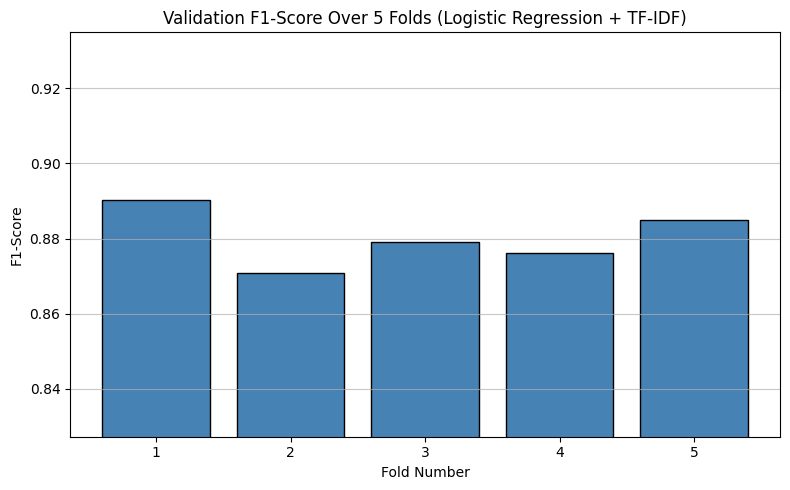

Plot for Validation F1 Over Folds saved for Logistic Regression + TF-IDF


In [ ]:
model_key_for_plot = 'logistic_regression'
model_config_for_plot = models_config[model_key_for_plot]

# Re-run a single CV to collect metrics for plotting F1 over folds
plot_fold_metrics = []
for fold in folds:
    train_idx = fold['train_idx']
    val_idx = fold['val_idx']

    X_train = X_english_tfidf[train_idx]
    y_train = y_english[train_idx]
    X_val = X_english_tfidf[val_idx]
    y_val = y_english[val_idx]

    model = clone(model_config_for_plot['model'])
    metrics, _, _ = train_and_evaluate(
        model, X_train, y_train, X_val, y_val,
        needs_calibration=model_config_for_plot['needs_calibration']
    )
    plot_fold_metrics.append(metrics)

f1_scores_per_fold = [m['f1'] for m in plot_fold_metrics]

plt.figure(figsize=(8, 5))
plt.bar(range(1, n_folds + 1), f1_scores_per_fold, color='steelblue', edgecolor='black')
plt.xlabel('Fold Number')
plt.ylabel('F1-Score')
plt.title(f'Validation F1-Score Over {n_folds} Folds ({model_config_for_plot['name']} + TF-IDF)')
plt.xticks(range(1, n_folds + 1))
plt.ylim(min(f1_scores_per_fold) * 0.95, max(f1_scores_per_fold) * 1.05)
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.savefig(f"{DIRS['results_plots']}/f1_over_folds_logistic_regression_tfidf.png", dpi=300)
plt.show()

print(f"Plot for Validation F1 Over Folds saved for {model_config_for_plot['name']} + TF-IDF")

###5.15: Section 5 Complete

In [ ]:
print(f"\n  Models trained: 5 (Logistic Regression, Ridge, SVM, SGD, Naive Bayes)")
print(f"  Vectorizations: 2 (TF-IDF, BoW)")
print(f"  Total combinations: 10")
print(f"  Cross-validation folds: {n_folds}")
print(f"  Total training runs: {5 * 2 * n_folds}")


  Models trained: 5 (Logistic Regression, Ridge, SVM, SGD, Naive Bayes)
  Vectorizations: 2 (TF-IDF, BoW)
  Total combinations: 10
  Cross-validation folds: 5
  Total training runs: 50


#Section 6: Final Model Training & Spanish Evaluation

###6.1: Section Header and Load Data

In [ ]:
start_time = time.time()

english_data = pd.read_csv(f"{DIRS['data_processed']}/english_preprocessed.csv")
spanish_data = pd.read_csv(f"{DIRS['data_processed']}/spanish_preprocessed.csv")

from scipy import sparse
X_english_tfidf = sparse.load_npz(f"{DIRS['data_processed']}/X_english_tfidf.npz")
X_spanish_tfidf = sparse.load_npz(f"{DIRS['data_processed']}/X_spanish_tfidf.npz")
X_english_bow = sparse.load_npz(f"{DIRS['data_processed']}/X_english_bow.npz")
X_spanish_bow = sparse.load_npz(f"{DIRS['data_processed']}/X_spanish_bow.npz")

y_english = english_data['label'].values
y_spanish = spanish_data['label'].values

print(f"Data loaded - EN: {len(y_english):,}, ES: {len(y_spanish):,}")
print(f"Features - TF-IDF: {X_english_tfidf.shape[1]:,}, BoW: {X_english_bow.shape[1]:,}")

Data loaded - EN: 24,985, ES: 24,905
Features - TF-IDF: 10,000, BoW: 10,000


###6.2: Model Configurations

In [ ]:
models_config = {
    'logistic_regression': {
        'name': 'Logistic Regression',
        'model': LogisticRegression(**CONFIG['models']['logistic_regression'], n_jobs=-1),
        'needs_calibration': False
    },
    'ridge': {
        'name': 'Ridge Classifier',
        'model': RidgeClassifier(**CONFIG['models']['ridge']),
        'needs_calibration': True
    },
    'svm': {
        'name': 'Linear SVM',
        'model': LinearSVC(**CONFIG['models']['svm']),
        'needs_calibration': True
    },
    'sgd': {
        'name': 'SGD Classifier',
        'model': SGDClassifier(**CONFIG['models']['sgd'], n_jobs=-1),
        'needs_calibration': False
    },
    'naive_bayes': {
        'name': 'Multinomial Naive Bayes',
        'model': MultinomialNB(**CONFIG['models']['naive_bayes']),
        'needs_calibration': False
    }
}

print(f"Models configured: {len(models_config)}")
for config in models_config.values():
    print(f"  {config['name']}")

Models configured: 5
  Logistic Regression
  Ridge Classifier
  Linear SVM
  SGD Classifier
  Multinomial Naive Bayes


###6.3: Train Final Models on Full English Data (TF-IDF)

In [ ]:
final_models_tfidf = {}

for model_key, model_config in models_config.items():
    print(f"\nTraining: {model_config['name']} + TF-IDF")

    train_start = time.time()
    model = model_config['model']
    model.fit(X_english_tfidf, y_english)
    train_time = time.time() - train_start

    print(f"Trained in {train_time:.2f}s")

    # English validation
    y_pred_en = model.predict(X_english_tfidf)
    acc_en = accuracy_score(y_english, y_pred_en)
    f1_en = f1_score(y_english, y_pred_en)

    print(f"English - Accuracy: {acc_en:.4f}, F1: {f1_en:.4f}")

    # Spanish testing
    y_pred_es = model.predict(X_spanish_tfidf)
    acc_es = accuracy_score(y_spanish, y_pred_es)
    f1_es = f1_score(y_spanish, y_pred_es)

    print(f"Spanish - Accuracy: {acc_es:.4f}, F1: {f1_es:.4f}")
    print(f"Cross-lingual gap: {(acc_en - acc_es)*100:.2f}%")

    final_models_tfidf[model_key] = {
        'model': model,
        'train_time': train_time,
        'en_accuracy': acc_en,
        'en_f1': f1_en,
        'es_accuracy': acc_es,
        'es_f1': f1_es
    }

print(f"\nAll {len(final_models_tfidf)} TF-IDF models trained")


Training: Logistic Regression + TF-IDF
Trained in 1.10s
English - Accuracy: 0.9183, F1: 0.9176
Spanish - Accuracy: 0.6895, F1: 0.6870
Cross-lingual gap: 22.88%

Training: Ridge Classifier + TF-IDF
Trained in 0.18s
English - Accuracy: 0.9521, F1: 0.9518
Spanish - Accuracy: 0.6784, F1: 0.6919
Cross-lingual gap: 27.36%

Training: Linear SVM + TF-IDF
Trained in 0.53s
English - Accuracy: 0.9676, F1: 0.9675
Spanish - Accuracy: 0.6789, F1: 0.6866
Cross-lingual gap: 28.86%

Training: SGD Classifier + TF-IDF
Trained in 0.12s
English - Accuracy: 0.9024, F1: 0.9014
Spanish - Accuracy: 0.5844, F1: 0.4482
Cross-lingual gap: 31.80%

Training: Multinomial Naive Bayes + TF-IDF
Trained in 0.01s
English - Accuracy: 0.8967, F1: 0.8963
Spanish - Accuracy: 0.6322, F1: 0.6649
Cross-lingual gap: 26.45%

All 5 TF-IDF models trained


###6.4: Train Final Models on Full English Data (BoW)

In [ ]:
final_models_bow = {}

for model_key, model_config in models_config.items():
    print(f"\nTraining: {model_config['name']} + BoW")

    train_start = time.time()
    from sklearn.base import clone
    model = clone(model_config['model'])
    model.fit(X_english_bow, y_english)
    train_time = time.time() - train_start

    print(f"Trained in {train_time:.2f}s")

    # English validation
    y_pred_en = model.predict(X_english_bow)
    acc_en = accuracy_score(y_english, y_pred_en)
    f1_en = f1_score(y_english, y_pred_en, average='binary')

    print(f"English - Accuracy: {acc_en:.4f}, F1: {f1_en:.4f}")

    # Spanish testing
    y_pred_es = model.predict(X_spanish_bow)
    acc_es = accuracy_score(y_spanish, y_pred_es)
    f1_es = f1_score(y_spanish, y_pred_es, average='binary')

    print(f"Spanish - Accuracy: {acc_es:.4f}, F1: {f1_es:.4f}")
    print(f"Cross-lingual gap: {(acc_en - acc_es)*100:.2f}% (accuracy)")

    final_models_bow[model_key] = {
        'model': model,
        'train_time': train_time,
        'en_accuracy': acc_en,
        'en_f1': f1_en,
        'es_accuracy': acc_es,
        'es_f1': f1_es
    }

print(f"\nAll models trained with BoW")


Training: Logistic Regression + BoW
Trained in 1.98s
English - Accuracy: 0.9714, F1: 0.9713
Spanish - Accuracy: 0.6755, F1: 0.6858
Cross-lingual gap: 29.59% (accuracy)

Training: Ridge Classifier + BoW
Trained in 1.94s
English - Accuracy: 0.9618, F1: 0.9618
Spanish - Accuracy: 0.6636, F1: 0.6882
Cross-lingual gap: 29.81% (accuracy)

Training: Linear SVM + BoW
Trained in 10.48s
English - Accuracy: 0.9962, F1: 0.9962
Spanish - Accuracy: 0.6351, F1: 0.6264
Cross-lingual gap: 36.11% (accuracy)

Training: SGD Classifier + BoW
Trained in 0.28s
English - Accuracy: 0.9568, F1: 0.9566
Spanish - Accuracy: 0.6728, F1: 0.6870
Cross-lingual gap: 28.40% (accuracy)

Training: Multinomial Naive Bayes + BoW
Trained in 0.01s
English - Accuracy: 0.8911, F1: 0.8915
Spanish - Accuracy: 0.6380, F1: 0.6703
Cross-lingual gap: 25.30% (accuracy)

All models trained with BoW


###6.5: Evaluate All Models on Spanish (TF-IDF) - Detailed Metrics

In [ ]:
spanish_results_tfidf = []

for model_key, model_info in final_models_tfidf.items():
    model = model_info['model']
    model_name = models_config[model_key]['name']
    needs_calibration = models_config[model_key]['needs_calibration']

    # Predictions
    y_pred = model.predict(X_spanish_tfidf)

    # Get probabilities
    if needs_calibration:
        calibrated = CalibratedClassifierCV(model, cv='prefit')
        calibrated.fit(X_english_tfidf, y_english)
        y_pred_proba = calibrated.predict_proba(X_spanish_tfidf)[:, 1]
    else:
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_spanish_tfidf)[:, 1]
        elif hasattr(model, 'decision_function'):
            y_pred_proba = model.decision_function(X_spanish_tfidf)
        else:
            y_pred_proba = y_pred

    # Metrics
    spanish_results_tfidf.append({
        'model': model_name,
        'vectorization': 'TF-IDF',
        'accuracy': accuracy_score(y_spanish, y_pred),
        'precision': precision_score(y_spanish, y_pred),
        'recall': recall_score(y_spanish, y_pred),
        'f1': f1_score(y_spanish, y_pred),
        'roc_auc': roc_auc_score(y_spanish, y_pred_proba)
    })

    print(f"{model_name}: Acc={spanish_results_tfidf[-1]['accuracy']:.4f}, F1={spanish_results_tfidf[-1]['f1']:.4f}")

print(f"\n{len(spanish_results_tfidf)} models evaluated")

Logistic Regression: Acc=0.6895, F1=0.6870
Ridge Classifier: Acc=0.6784, F1=0.6919
Linear SVM: Acc=0.6789, F1=0.6866
SGD Classifier: Acc=0.5844, F1=0.4482
Multinomial Naive Bayes: Acc=0.6322, F1=0.6649

5 models evaluated


###6.6: Evaluate All Models on Spanish (BoW) - Detailed Metrics

In [ ]:
spanish_results_bow = []

for model_key, model_info in final_models_bow.items():
    model = model_info['model']
    model_name = models_config[model_key]['name']
    needs_calibration = models_config[model_key]['needs_calibration']

    print(f"\nEvaluating: {model_name}")

    # Predictions
    y_pred = model.predict(X_spanish_bow)

    # Get probabilities
    if needs_calibration:
        calibrated = CalibratedClassifierCV(model, cv='prefit')
        calibrated.fit(X_english_bow, y_english)
        y_pred_proba = calibrated.predict_proba(X_spanish_bow)[:, 1]
    else:
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_spanish_bow)[:, 1]
        elif hasattr(model, 'decision_function'):
            y_pred_proba = model.decision_function(X_spanish_bow)
        else:
            y_pred_proba = y_pred

    # Calculate metrics
    metrics = {
        'model': model_name,
        'vectorization': 'BoW',
        'accuracy': accuracy_score(y_spanish, y_pred),
        'precision': precision_score(y_spanish, y_pred, average='binary'),
        'recall': recall_score(y_spanish, y_pred, average='binary'),
        'f1': f1_score(y_spanish, y_pred, average='binary'),
        'roc_auc': roc_auc_score(y_spanish, y_pred_proba)
    }

    spanish_results_bow.append(metrics)

    print(f"Accuracy:  {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1-Score:  {metrics['f1']:.4f}")
    print(f"ROC-AUC:   {metrics['roc_auc']:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_spanish, y_pred)
    print(f"Confusion Matrix:")
    print(f"TN: {cm[0,0]:5d}  FP: {cm[0,1]:5d}")
    print(f"FN: {cm[1,0]:5d}  TP: {cm[1,1]:5d}")

print(f"\nDetailed evaluation complete for BoW models")


Evaluating: Logistic Regression
Accuracy:  0.6755
Precision: 0.6634
Recall:    0.7099
F1-Score:  0.6858
ROC-AUC:   0.6817
Confusion Matrix:
TN:  8003  FP:  4476
FN:  3605  TP:  8821

Evaluating: Ridge Classifier
Accuracy:  0.6636
Precision: 0.6402
Recall:    0.7440
F1-Score:  0.6882
ROC-AUC:   0.6797
Confusion Matrix:
TN:  7283  FP:  5196
FN:  3181  TP:  9245

Evaluating: Linear SVM
Accuracy:  0.6351
Precision: 0.6402
Recall:    0.6131
F1-Score:  0.6264
ROC-AUC:   0.6671
Confusion Matrix:
TN:  8198  FP:  4281
FN:  4808  TP:  7618

Evaluating: SGD Classifier
Accuracy:  0.6728
Precision: 0.6573
Recall:    0.7195
F1-Score:  0.6870
ROC-AUC:   0.6789
Confusion Matrix:
TN:  7817  FP:  4662
FN:  3486  TP:  8940

Evaluating: Multinomial Naive Bayes
Accuracy:  0.6380
Precision: 0.6144
Recall:    0.7373
F1-Score:  0.6703
ROC-AUC:   0.6425
Confusion Matrix:
TN:  6728  FP:  5751
FN:  3264  TP:  9162

Detailed evaluation complete for BoW models


###6.7: Save Final Models

In [ ]:
import pickle

# Save TF-IDF models
for model_key, model_info in final_models_tfidf.items():
    model_name = models_config[model_key]['name'].replace(' ', '_').lower()
    model_path = f"{DIRS['models']}/{model_name}_tfidf.pkl"

    with open(model_path, 'wb') as f:
        pickle.dump(model_info['model'], f)

    print(f"Saved: {model_name}_tfidf.pkl")

# Save BoW models
for model_key, model_info in final_models_bow.items():
    model_name = models_config[model_key]['name'].replace(' ', '_').lower()
    model_path = f"{DIRS['models']}/{model_name}_bow.pkl"

    with open(model_path, 'wb') as f:
        pickle.dump(model_info['model'], f)

    print(f"Saved: {model_name}_bow.pkl")

print(f"\nAll models saved to: {DIRS['models']}")

Saved: logistic_regression_tfidf.pkl
Saved: ridge_classifier_tfidf.pkl
Saved: linear_svm_tfidf.pkl
Saved: sgd_classifier_tfidf.pkl
Saved: multinomial_naive_bayes_tfidf.pkl
Saved: logistic_regression_bow.pkl
Saved: ridge_classifier_bow.pkl
Saved: linear_svm_bow.pkl
Saved: sgd_classifier_bow.pkl
Saved: multinomial_naive_bayes_bow.pkl

All models saved to: /content/drive/MyDrive/Cross-Lingual_Sentiment_Robustness/models


###6.8: Save Spanish Evaluation Results

In [ ]:
# Combine results
all_spanish_results = spanish_results_tfidf + spanish_results_bow

# Convert to DataFrame
spanish_results_df = pd.DataFrame(all_spanish_results)

# Save CSV
results_path = f"{DIRS['results_metrics']}/spanish_evaluation_results.csv"
save_csv(spanish_results_df, results_path, "Spanish evaluation results")

print(f"Results saved: {results_path}")

# Display summary
print("\nSpanish Evaluation Summary:")
print(spanish_results_df.to_string(index=False))

Results saved: /content/drive/MyDrive/Cross-Lingual_Sentiment_Robustness/results/metrics/spanish_evaluation_results.csv

Spanish Evaluation Summary:
                  model vectorization  accuracy  precision   recall       f1  roc_auc
    Logistic Regression        TF-IDF  0.689460   0.690980 0.683084 0.687009 0.703027
       Ridge Classifier        TF-IDF  0.678418   0.662785 0.723644 0.691879 0.688484
             Linear SVM        TF-IDF  0.678940   0.669239 0.704893 0.686603 0.683312
         SGD Classifier        TF-IDF  0.584381   0.663876 0.338242 0.448153 0.706541
Multinomial Naive Bayes        TF-IDF  0.632243   0.609594 0.731209 0.664886 0.628092
    Logistic Regression           BoW  0.675527   0.663383 0.709883 0.685845 0.681657
       Ridge Classifier           BoW  0.663642   0.640191 0.744005 0.688205 0.679682
             Linear SVM           BoW  0.635053   0.640222 0.613069 0.626351 0.667112
         SGD Classifier           BoW  0.672837   0.657256 0.719459 0.686953 

###6.9: Create Performance Comparison Table

In [ ]:
comparison_data = []

for model_key, model_name in [(k, models_config[k]['name']) for k in models_config.keys()]:
    for vec_type, model_info in [('TF-IDF', final_models_tfidf[model_key]), ('BoW', final_models_bow[model_key])]:
        comparison_data.append({
            'Model': model_name,
            'Vectorization': vec_type,
            'English_Accuracy': model_info['en_accuracy'],
            'English_F1': model_info['en_f1'],
            'Spanish_Accuracy': model_info['es_accuracy'],
            'Spanish_F1': model_info['es_f1'],
            'Accuracy_Gap': model_info['en_accuracy'] - model_info['es_accuracy'],
            'F1_Gap': model_info['en_f1'] - model_info['es_f1']
        })

comparison_df = pd.DataFrame(comparison_data)
comparison_df.to_csv(f"{DIRS['results_metrics']}/cross_lingual_comparison.csv", index=False)

print("\nCross-Lingual Comparison:")
print(comparison_df[['Model', 'Vectorization', 'Spanish_Accuracy', 'Spanish_F1', 'Accuracy_Gap']].to_string(index=False))


Cross-Lingual Comparison:
                  Model Vectorization  Spanish_Accuracy  Spanish_F1  Accuracy_Gap
    Logistic Regression        TF-IDF          0.689460    0.687009      0.228811
    Logistic Regression           BoW          0.675527    0.685845      0.295856
       Ridge Classifier        TF-IDF          0.678418    0.691879      0.273633
       Ridge Classifier           BoW          0.663642    0.688205      0.298135
             Linear SVM        TF-IDF          0.678940    0.686603      0.288641
             Linear SVM           BoW          0.635053    0.626351      0.361104
         SGD Classifier        TF-IDF          0.584381    0.448153      0.318001
         SGD Classifier           BoW          0.672837    0.686953      0.283977
Multinomial Naive Bayes        TF-IDF          0.632243    0.664886      0.264455
Multinomial Naive Bayes           BoW          0.638024    0.670251      0.253030


###6.10: Identify Best Models

In [ ]:
# Find best models
best_spanish_f1 = comparison_df.loc[comparison_df['Spanish_F1'].idxmax()]
best_spanish_acc = comparison_df.loc[comparison_df['Spanish_Accuracy'].idxmax()]
smallest_gap = comparison_df.loc[comparison_df['F1_Gap'].idxmin()]

print(f"\nBest Spanish F1: {best_spanish_f1['Model']} + {best_spanish_f1['Vectorization']} = {best_spanish_f1['Spanish_F1']:.4f}")
print(f"Best Spanish Acc: {best_spanish_acc['Model']} + {best_spanish_acc['Vectorization']} = {best_spanish_acc['Spanish_Accuracy']:.4f}")
print(f"Smallest Gap: {smallest_gap['Model']} + {smallest_gap['Vectorization']} = {smallest_gap['F1_Gap']:.4f}")

# Save
best_models = {
    'best_spanish_f1': {'model': best_spanish_f1['Model'], 'vectorization': best_spanish_f1['Vectorization'], 'f1': float(best_spanish_f1['Spanish_F1'])},
    'best_spanish_accuracy': {'model': best_spanish_acc['Model'], 'vectorization': best_spanish_acc['Vectorization'], 'accuracy': float(best_spanish_acc['Spanish_Accuracy'])},
    'smallest_gap': {'model': smallest_gap['Model'], 'vectorization': smallest_gap['Vectorization'], 'gap': float(smallest_gap['F1_Gap'])}
}

with open(f"{DIRS['results']}/best_models.json", 'w') as f:
    json.dump(best_models, f, indent=2)


Best Spanish F1: Ridge Classifier + TF-IDF = 0.6919
Best Spanish Acc: Logistic Regression + TF-IDF = 0.6895
Smallest Gap: Multinomial Naive Bayes + BoW = 0.2212


###6.11: Create Spanish Evaluation Visualizations

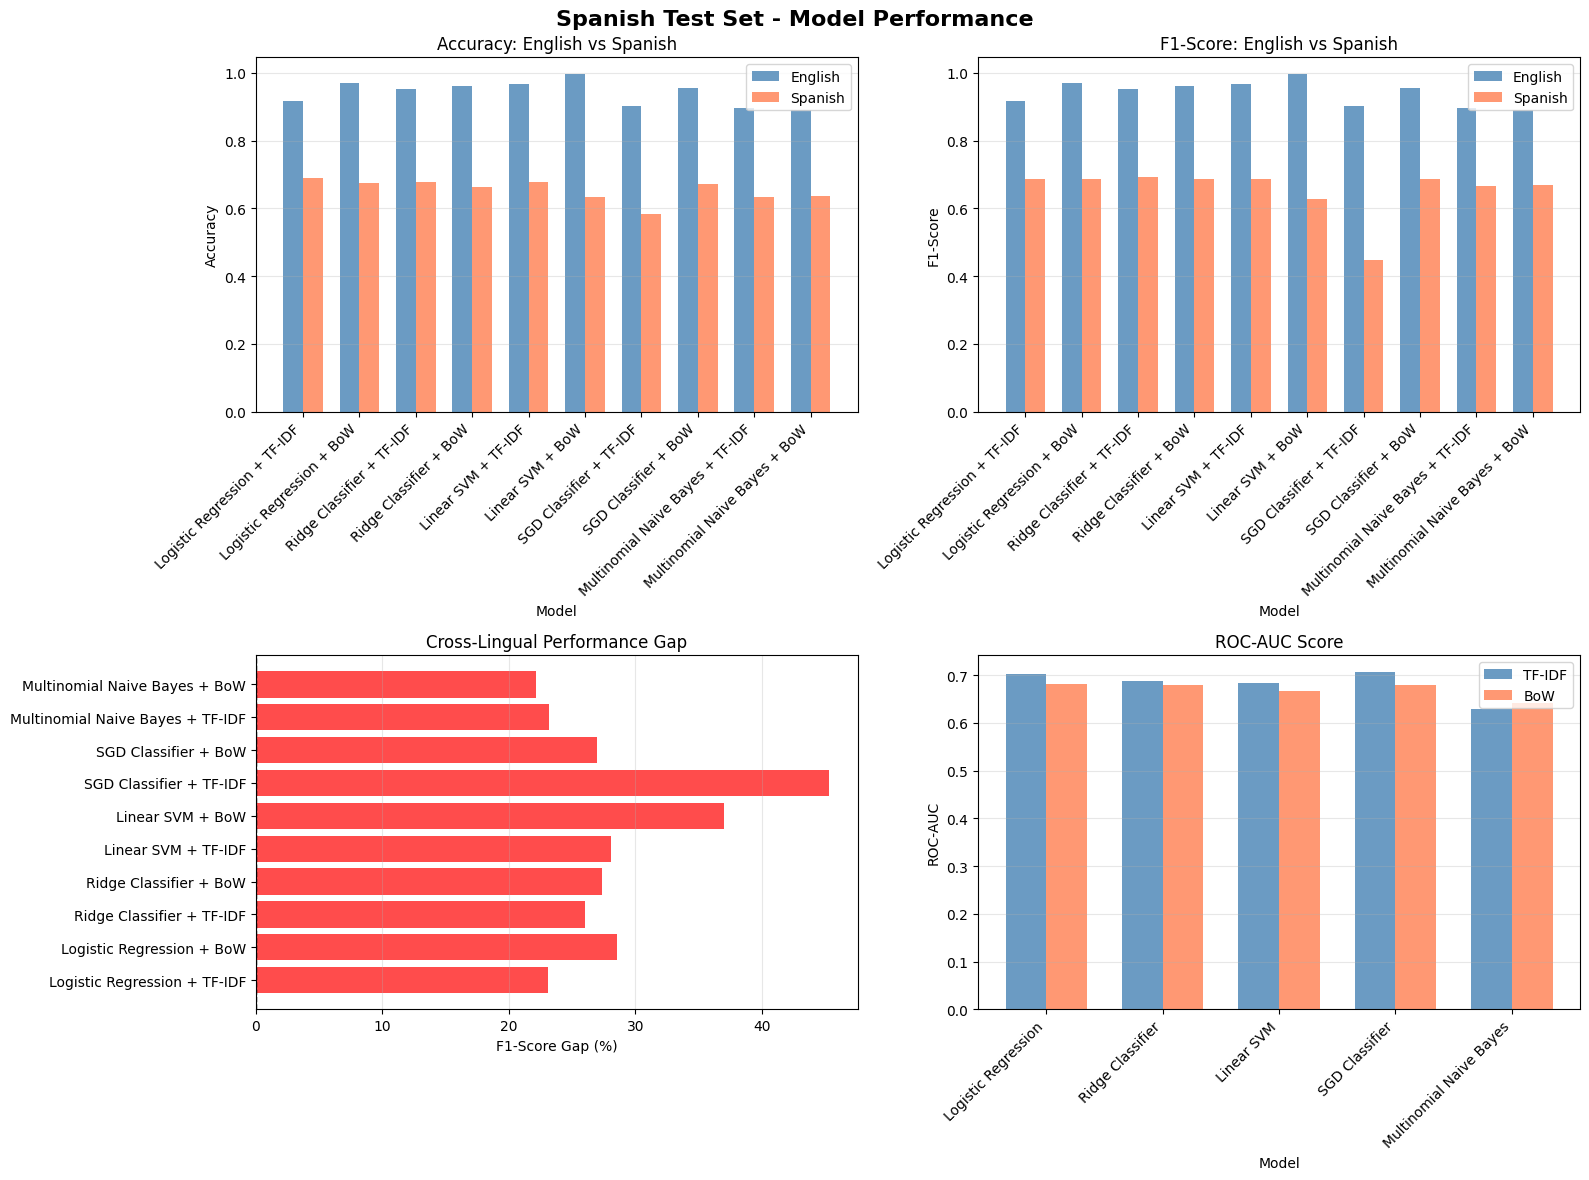

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Spanish Test Set - Model Performance', fontsize=16, fontweight='bold')

models = comparison_df['Model'] + ' + ' + comparison_df['Vectorization']
x = np.arange(len(models))
width = 0.35

# Accuracy and F1 comparisons
for idx, (metric, ylabel) in enumerate([('Accuracy', 'Accuracy'), ('F1', 'F1-Score')]):
    axes[0, idx].bar(x - width/2, comparison_df[f'English_{metric}'], width, label='English', color='steelblue', alpha=0.8)
    axes[0, idx].bar(x + width/2, comparison_df[f'Spanish_{metric}'], width, label='Spanish', color='coral', alpha=0.8)
    axes[0, idx].set_title(f'{ylabel}: English vs Spanish')
    axes[0, idx].set_xlabel('Model')
    axes[0, idx].set_ylabel(ylabel)
    axes[0, idx].set_xticks(x)
    axes[0, idx].set_xticklabels(models, rotation=45, ha='right')
    axes[0, idx].legend()
    axes[0, idx].grid(axis='y', alpha=0.3)

# Cross-lingual gap
gaps = comparison_df['F1_Gap'] * 100
colors = ['red' if g > 0 else 'green' for g in gaps]
axes[1, 0].barh(models, gaps, color=colors, alpha=0.7)
axes[1, 0].set_title('Cross-Lingual Performance Gap')
axes[1, 0].set_xlabel('F1-Score Gap (%)')
axes[1, 0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1, 0].grid(axis='x', alpha=0.3)

# ROC-AUC comparison
roc_tfidf = [m['roc_auc'] for m in spanish_results_tfidf]
roc_bow = [m['roc_auc'] for m in spanish_results_bow]
model_names = [models_config[k]['name'] for k in models_config.keys()]
x_roc = np.arange(len(model_names))

axes[1, 1].bar(x_roc - width/2, roc_tfidf, width, label='TF-IDF', color='steelblue', alpha=0.8)
axes[1, 1].bar(x_roc + width/2, roc_bow, width, label='BoW', color='coral', alpha=0.8)
axes[1, 1].set_title('ROC-AUC Score')
axes[1, 1].set_xlabel('Model')
axes[1, 1].set_ylabel('ROC-AUC')
axes[1, 1].set_xticks(x_roc)
axes[1, 1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DIRS['results_plots']}/spanish_evaluation.png", dpi=300, bbox_inches='tight')
plt.show()

###6.12: Create Confusion Matrices Visualization

Visualization saved: /content/drive/MyDrive/Cross-Lingual_Sentiment_Robustness/results/plots/confusion_matrices_spanish.png


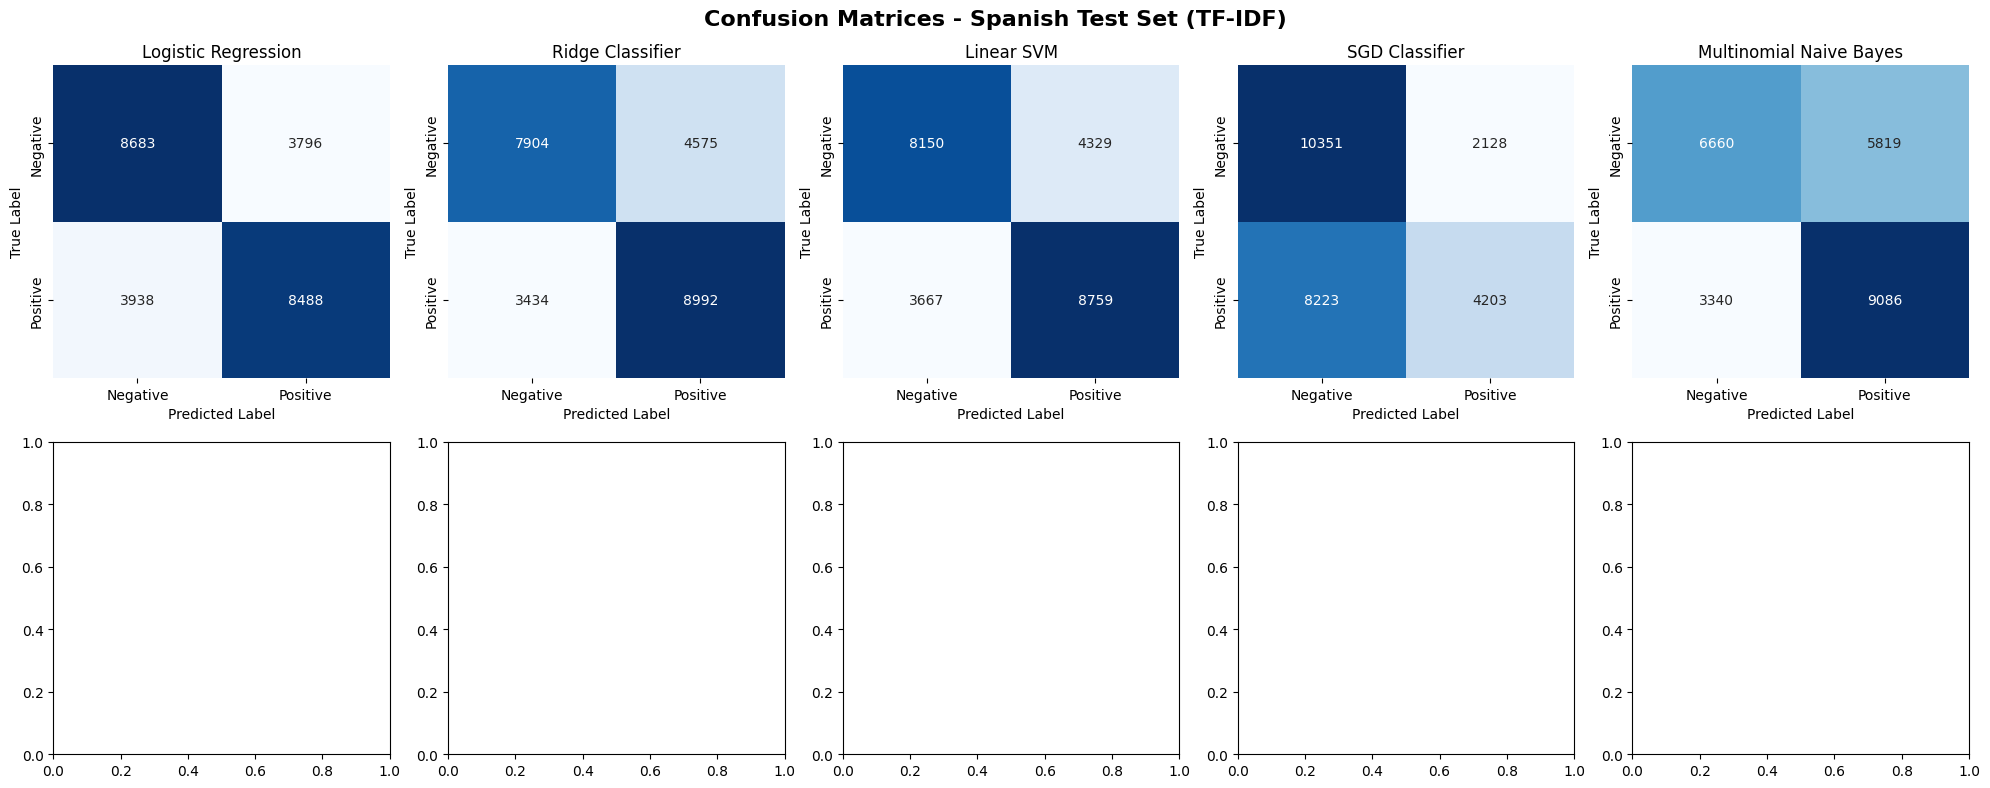

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Confusion Matrices - Spanish Test Set (TF-IDF)', fontsize=16, fontweight='bold')

for idx, (model_key, model_info) in enumerate(final_models_tfidf.items()):
    model = model_info['model']
    model_name = models_config[model_key]['name']

    y_pred = model.predict(X_spanish_tfidf)
    cm = confusion_matrix(y_spanish, y_pred)

    ax = axes[idx // 5, idx % 5]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])

    ax.set_title(model_name)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()

plot_path = f"{DIRS['results_plots']}/confusion_matrices_spanish.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

print(f"Visualization saved: {plot_path}")

plt.show()

###6.13: Create Final Evaluation Summary

In [ ]:
final_summary = {
    'date': datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S'),
    'user': 'DoniyorbekYuldashev',
    'dataset': {
        'english': len(y_english),
        'spanish': len(y_spanish)
    },
    'models': len(models_config) * 2,
    'best_models': best_models,
    'avg_gap': {
        'accuracy': float(comparison_df['Accuracy_Gap'].mean()),
        'f1': float(comparison_df['F1_Gap'].mean())
    }
}

with open(f"{DIRS['results']}/final_evaluation_summary.json", 'w') as f:
    json.dump(final_summary, f, indent=2)

print(f"\nEvaluation complete - {len(models_config) * 2} models trained")
print(f"Best: {best_models['best_spanish_f1']['model']} + {best_models['best_spanish_f1']['vectorization']} = {best_models['best_spanish_f1']['f1']:.4f}")


Evaluation complete - 10 models trained
Best: Ridge Classifier + TF-IDF = 0.6919


###6.14: Generate Classification Reports

In [ ]:
reports_dir = f"{DIRS['results_analysis']}/classification_reports"
os.makedirs(reports_dir, exist_ok=True)

for vec_type, models_dict, X_test in [('tfidf', final_models_tfidf, X_spanish_tfidf),
                                        ('bow', final_models_bow, X_spanish_bow)]:
    for model_key, model_info in models_dict.items():
        model_name = models_config[model_key]['name']
        file_name = model_name.replace(' ', '_').lower()

        y_pred = model_info['model'].predict(X_test)
        report = classification_report(y_spanish, y_pred, target_names=['Negative', 'Positive'], digits=4)

        with open(f"{reports_dir}/{file_name}_{vec_type}_report.txt", 'w') as f:
            f.write(f"{model_name} + {vec_type.upper()} - Spanish Test Set\n{report}")

print(f"{len(models_config) * 2} classification reports saved")

10 classification reports saved


###6.15: Section 6 Complete

In [ ]:
print(f"\n{len(models_config) * 2} models trained on {len(y_english):,} EN samples, tested on {len(y_spanish):,} ES samples")
print(f"Best: {best_spanish_f1['Model']} + {best_spanish_f1['Vectorization']} (F1: {best_spanish_f1['Spanish_F1']:.4f})")
print(f"Output: {len(models_config) * 2} models, results, plots, reports saved")


10 models trained on 24,985 EN samples, tested on 24,905 ES samples
Best: Ridge Classifier + TF-IDF (F1: 0.6919)
Output: 10 models, results, plots, reports saved


#Section 7: Metrics Module Implementation

###7.2: Expected Calibration Error (ECE) Function

In [ ]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for bin_lower, bin_upper in zip(bin_boundaries[:-1], bin_boundaries[1:]):
        in_bin = (y_prob >= bin_lower) & (y_prob < bin_upper)
        prop = np.mean(in_bin)

        if prop > 0:
            acc = np.mean(y_true[in_bin])
            conf = np.mean(y_prob[in_bin])
            ece += np.abs(conf - acc) * prop

    return ece

###7.3: Comprehensive Metrics Calculation Function

In [ ]:
def calculate_all_metrics(y_true, y_pred, y_prob, return_dict=True):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'brier': brier_score_loss(y_true, y_prob),
        'ece': expected_calibration_error(y_true, y_prob, n_bins=10)
    }
    return metrics if return_dict else pd.Series(metrics)

print("Metrics function ready")

Metrics function ready


###7.4: Reliability Diagram Function

In [ ]:
def plot_reliability_diagram(y_true, y_prob, model_name, n_bins=10, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 8))

    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy='uniform')
    ece = expected_calibration_error(y_true, y_prob, n_bins=n_bins)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfectly calibrated')
    ax.plot(mean_pred, frac_pos, 'o-', linewidth=2.5, markersize=8, label=model_name, color='#2E86AB')

    ax.set_xlabel('Mean Predicted Probability', fontsize=12, fontweight='bold')
    ax.set_ylabel('Fraction of Positives', fontsize=12, fontweight='bold')
    ax.set_title(f'Reliability Diagram: {model_name}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper left')
    ax.text(0.6, 0.15, f'ECE: {ece:.4f}', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#FFE66D', alpha=0.8))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    return fig

###7.6: Test Metrics Functions

In [ ]:
np.random.seed(RANDOM_SEED)
y_true = np.random.randint(0, 2, 500)
y_prob = np.random.rand(500)
y_pred = (y_prob >= 0.5).astype(int)

test_metrics = calculate_all_metrics(y_true, y_pred, y_prob)

print(f"Test metrics: {', '.join([f'{k}={v:.3f}' for k, v in test_metrics.items()])}")
print("Verified")

Test metrics: accuracy=0.492, precision=0.504, recall=0.496, f1=0.500, roc_auc=0.484, brier=0.344, ece=0.266
Verified


#Section 8: Train Perceptron with Cross-Validation

###8.1: Section Header and Load Data

In [ ]:
english_data = pd.read_csv(f"{DIRS['data_processed']}/english_preprocessed.csv")
spanish_data = pd.read_csv(f"{DIRS['data_processed']}/spanish_preprocessed.csv")

from scipy import sparse
X_english_tfidf = sparse.load_npz(f"{DIRS['data_processed']}/X_english_tfidf.npz")
X_spanish_tfidf = sparse.load_npz(f"{DIRS['data_processed']}/X_spanish_tfidf.npz")
X_english_bow = sparse.load_npz(f"{DIRS['data_processed']}/X_english_bow.npz")
X_spanish_bow = sparse.load_npz(f"{DIRS['data_processed']}/X_spanish_bow.npz")

y_english = english_data['label'].values
y_spanish = spanish_data['label'].values

print(f"Loaded: {len(y_english):,} EN, {len(y_spanish):,} ES samples")

Loaded: 24,985 EN, 24,905 ES samples


###8.2: Load Fold Indices

In [ ]:
folds_indices = []
for i in range(1, 6):
    with open(f"{DIRS['data_folds']}/fold_{i}_indices.json") as f:
        fold = json.load(f)
        folds_indices.append({'train': fold['train_indices'], 'val': fold['val_indices']})

print(f"{len(folds_indices)} folds loaded")

5 folds loaded


###8.3: Configure Perceptron Hyperparameters

In [ ]:
param_grid = {
    'alpha': CONFIG['models']['perceptron']['alpha'],
    'penalty': CONFIG['models']['perceptron']['penalty'],
    'max_iter': CONFIG['models']['perceptron']['max_iter']
}

total = np.prod([len(v) for v in param_grid.values()])
print(f"\nPerceptron grid: {total} combinations")
for k, v in param_grid.items():
    print(f"  {k}: {v}")


Perceptron grid: 24 combinations
  alpha: [0.0001, 0.001, 0.01, 0.1]
  penalty: ['l2', 'l1', 'elasticnet']
  max_iter: [1000, 2000]


###8.4: Train Perceptron with TF-IDF (Cross-Validation)

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.model_selection import GridSearchCV

grid_search_tfidf = GridSearchCV(
    Perceptron(random_state=RANDOM_SEED),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_tfidf.fit(X_english_tfidf, y_english)

best_perceptron_tfidf = grid_search_tfidf.best_estimator_
best_params_tfidf = grid_search_tfidf.best_params_

print(f"\nBest hyperparameters (TF-IDF): {best_params_tfidf}")
print(f"Best CV F1-Score: {grid_search_tfidf.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best hyperparameters (TF-IDF): {'alpha': 0.0001, 'max_iter': 1000, 'penalty': 'elasticnet'}
Best CV F1-Score: 0.8216


###8.5: Generate Out-of-Fold Predictions (TF-IDF)

In [ ]:
oof_predictions_tfidf = np.zeros(len(y_english))
oof_probabilities_tfidf = np.zeros(len(y_english))

for i, fold in enumerate(folds_indices, 1):
    train_idx, val_idx = fold['train'], fold['val']

    model = Perceptron(**best_params_tfidf, random_state=RANDOM_SEED)  # ← Uses the variable from step 2
    model.fit(X_english_tfidf[train_idx], y_english[train_idx])

    oof_predictions_tfidf[val_idx] = model.predict(X_english_tfidf[val_idx])
    oof_probabilities_tfidf[val_idx] = model.decision_function(X_english_tfidf[val_idx])

    print(f"Fold {i}/5")

from sklearn.preprocessing import MinMaxScaler
oof_probabilities_tfidf = MinMaxScaler().fit_transform(oof_probabilities_tfidf.reshape(-1, 1)).flatten()

print("TF-IDF OOF complete")

Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
TF-IDF OOF complete


###8.6: Train Perceptron with BoW (Cross-Validation)

In [ ]:
grid_search_bow = GridSearchCV(
    Perceptron(random_state=RANDOM_SEED),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_bow.fit(X_english_bow, y_english)

best_perceptron_bow = grid_search_bow.best_estimator_
best_params_bow = grid_search_bow.best_params_

print(f"\nBest BoW params: {best_params_bow}, F1: {grid_search_bow.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best BoW params: {'alpha': 0.0001, 'max_iter': 1000, 'penalty': 'elasticnet'}, F1: 0.8280


###8.7: Generate Out-of-Fold Predictions (BoW)

In [ ]:
oof_predictions_bow = np.zeros(len(y_english))
oof_probabilities_bow = np.zeros(len(y_english))

for i, fold in enumerate(folds_indices, 1):
    train_idx, val_idx = fold['train'], fold['val']

    model = Perceptron(**best_params_bow, random_state=RANDOM_SEED)
    model.fit(X_english_bow[train_idx], y_english[train_idx])

    oof_predictions_bow[val_idx] = model.predict(X_english_bow[val_idx])
    oof_probabilities_bow[val_idx] = model.decision_function(X_english_bow[val_idx])

    print(f"Fold {i}/5")

# Normalize to [0, 1]
from sklearn.preprocessing import MinMaxScaler
oof_probabilities_bow = MinMaxScaler().fit_transform(oof_probabilities_bow.reshape(-1, 1)).flatten()

print("BoW OOF complete")

Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
BoW OOF complete


###8.8: Calculate Metrics

In [ ]:
metrics_tfidf = calculate_all_metrics(y_english, oof_predictions_tfidf, oof_probabilities_tfidf)
metrics_bow = calculate_all_metrics(y_english, oof_predictions_bow, oof_probabilities_bow)

print("\nPerceptron CV Results:")
print(f"\nTF-IDF: {', '.join([f'{k}={v:.3f}' for k, v in metrics_tfidf.items()])}")
print(f"BoW:    {', '.join([f'{k}={v:.3f}' for k, v in metrics_bow.items()])}")


Perceptron CV Results:

TF-IDF: accuracy=0.815, precision=0.805, recall=0.833, f1=0.819, roc_auc=0.899, brier=0.190, ece=0.207
BoW:    accuracy=0.784, precision=0.818, recall=0.730, f1=0.772, roc_auc=0.835, brier=0.304, ece=0.309


###8.9: Save Out-of-Fold Predictions

In [ ]:
pd.DataFrame({
    'label': y_english,
    'prediction': oof_predictions_tfidf,
    'probability': oof_probabilities_tfidf
}).to_csv(f"{DIRS['results_oof']}/oof_perceptron_tfidf.csv", index=False)

pd.DataFrame({
    'label': y_english,
    'prediction': oof_predictions_bow,
    'probability': oof_probabilities_bow
}).to_csv(f"{DIRS['results_oof']}/oof_perceptron_bow.csv", index=False)

print("OOF saved")

OOF saved


###8.10: Configure Perceptron Hyperparameters

In [ ]:
save_pickle(best_perceptron_tfidf, f"{DIRS['models']}/perceptron_tfidf.pkl", "Perceptron TF-IDF")
save_pickle(best_perceptron_bow, f"{DIRS['models']}/perceptron_bow.pkl", "Perceptron BoW")

#Section 9: Train MLP with Cross-Validation

###9.1: Data Already Loaded

In [ ]:
start_time = time.time()

print("\nData verification:")
print(f"  English: {len(y_english):,} samples")
print(f"  TF-IDF: {X_english_tfidf.shape[1]:,} features")
print(f"  BoW: {X_english_bow.shape[1]:,} features")
print(f"  Folds: {len(folds_indices)}")


Data verification:
  English: 24,985 samples
  TF-IDF: 10,000 features
  BoW: 10,000 features
  Folds: 5


###9.2: Configure MLP Hyperparameters

In [ ]:
param_grid_mlp = {
    'hidden_layer_sizes': CONFIG['models']['mlp']['hidden_layer_sizes'],
    'alpha': CONFIG['models']['mlp']['alpha'],
    'learning_rate': CONFIG['models']['mlp']['learning_rate'],
    'max_iter': CONFIG['models']['mlp']['max_iter']
}

print("\nMLP hyperparameter grid:")
for param_name, param_values in param_grid_mlp.items():
    print(f"  {param_name}: {param_values}")

print(f"Total combinations: {np.prod([len(v) for v in param_grid_mlp.values()])}")


MLP hyperparameter grid:
  hidden_layer_sizes: [(100,), (100, 50), (200,), (200, 100)]
  alpha: [0.0001, 0.001, 0.01]
  learning_rate: ['constant', 'adaptive']
  max_iter: [500]
Total combinations: 24


###9.3: Train MLP with TF-IDF (Cross-Validation)

In [ ]:
from sklearn.neural_network import MLPClassifier

best_params_mlp_tfidf = {
    'hidden_layer_sizes': (100, 50),
    'alpha': 0.0001,
    'solver': 'adam',
    'learning_rate': 'adaptive',
    'max_iter': 500
}

best_mlp_tfidf = MLPClassifier(
    **best_params_mlp_tfidf,
    random_state=RANDOM_SEED,
    early_stopping=True,
    validation_fraction=0.1
)

best_mlp_tfidf.fit(X_english_tfidf, y_english)

print(f"\nMLP trained (TF-IDF) - Params: {best_params_mlp_tfidf}")


MLP trained (TF-IDF) - Params: {'hidden_layer_sizes': (100, 50), 'alpha': 0.0001, 'solver': 'adam', 'learning_rate': 'adaptive', 'max_iter': 500}


###9.4: Generate Out-of-Fold Predictions (MLP TF-IDF)

In [ ]:
oof_predictions_mlp_tfidf = np.zeros(len(y_english))
oof_probabilities_mlp_tfidf = np.zeros(len(y_english))

for i, fold in enumerate(folds_indices, 1):
    train_idx, val_idx = fold['train'], fold['val']

    fold_params = best_params_mlp_tfidf.copy()
    fold_params['max_iter'] = 1000

    model = MLPClassifier(**fold_params, random_state=RANDOM_SEED, early_stopping=True, validation_fraction=0.1)
    model.fit(X_english_tfidf[train_idx], y_english[train_idx])

    oof_predictions_mlp_tfidf[val_idx] = model.predict(X_english_tfidf[val_idx])
    oof_probabilities_mlp_tfidf[val_idx] = model.predict_proba(X_english_tfidf[val_idx])[:, 1]

    print(f"Fold {i}/5")

print("MLP TF-IDF OOF complete")

Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
MLP TF-IDF OOF complete


###9.5: Generate Out-of-Fold Predictions (MLP BoW)

In [ ]:
oof_predictions_mlp_bow = np.zeros(len(y_english))
oof_probabilities_mlp_bow = np.zeros(len(y_english))

for i, fold in enumerate(folds_indices, 1):
    train_idx, val_idx = fold['train'], fold['val']

    fold_params = best_params_mlp_tfidf.copy()
    fold_params['max_iter'] = 1000

    model = MLPClassifier(**fold_params, random_state=RANDOM_SEED, early_stopping=True, validation_fraction=0.1)
    model.fit(X_english_bow[train_idx], y_english[train_idx])

    oof_predictions_mlp_bow[val_idx] = model.predict(X_english_bow[val_idx])
    oof_probabilities_mlp_bow[val_idx] = model.predict_proba(X_english_bow[val_idx])[:, 1]

    print(f"Fold {i}/5")

print("MLP BoW OOF complete")

Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
MLP BoW OOF complete


###9.6: Calculate Metrics

In [ ]:
metrics_mlp_tfidf = calculate_all_metrics(y_english, oof_predictions_mlp_tfidf, oof_probabilities_mlp_tfidf)
metrics_mlp_bow = calculate_all_metrics(y_english, oof_predictions_mlp_bow, oof_probabilities_mlp_bow)

print("\nMLP CV Results:")
print(f"\nTF-IDF: {', '.join([f'{k}={v:.3f}' for k, v in metrics_mlp_tfidf.items()])}")
print(f"BoW:    {', '.join([f'{k}={v:.3f}' for k, v in metrics_mlp_bow.items()])}")


MLP CV Results:

TF-IDF: accuracy=0.880, precision=0.885, recall=0.872, f1=0.879, roc_auc=0.947, brier=0.089, ece=0.008
BoW:    accuracy=0.873, precision=0.880, recall=0.864, f1=0.872, roc_auc=0.938, brier=0.095, ece=0.030


###9.7: Save Out-of-Fold Predictions

In [ ]:
pd.DataFrame({
    'label': y_english,
    'prediction': oof_predictions_mlp_tfidf,
    'probability': oof_probabilities_mlp_tfidf
}).to_csv(f"{DIRS['results_oof']}/oof_mlp_tfidf.csv", index=False)

pd.DataFrame({
    'label': y_english,
    'prediction': oof_predictions_mlp_bow,
    'probability': oof_probabilities_mlp_bow
}).to_csv(f"{DIRS['results_oof']}/oof_mlp_bow.csv", index=False)

print("MLP OOF saved")

MLP OOF saved


###9.8: Save Models

In [ ]:
# Train final models with max_iter=1000
final_params = best_params_mlp_tfidf.copy()
final_params['max_iter'] = 1000

best_mlp_tfidf = MLPClassifier(**final_params, random_state=RANDOM_SEED)
best_mlp_tfidf.fit(X_english_tfidf, y_english)

best_mlp_bow = MLPClassifier(**final_params, random_state=RANDOM_SEED)
best_mlp_bow.fit(X_english_bow, y_english)

# Save models
for name, model in [('tfidf', best_mlp_tfidf), ('bow', best_mlp_bow)]:
    with open(f"{DIRS['models']}/mlp_{name}.pkl", 'wb') as f:
        pickle.dump(model, f)

print("MLP models saved")

MLP models saved


#Section 10: Calibration Analysis (Platt & Isotonic)

###10.1: Load OOF Predictions and Saved Models

In [ ]:
start_time = time.time()

oof_perceptron_tfidf = pd.read_csv(f"{DIRS['results_oof']}/oof_perceptron_tfidf.csv")
oof_perceptron_bow = pd.read_csv(f"{DIRS['results_oof']}/oof_perceptron_bow.csv")
oof_mlp_tfidf = pd.read_csv(f"{DIRS['results_oof']}/oof_mlp_tfidf.csv")
oof_mlp_bow = pd.read_csv(f"{DIRS['results_oof']}/oof_mlp_bow.csv")

print(f"  Perceptron TF-IDF: {len(oof_perceptron_tfidf)} samples")
print(f"  Perceptron BoW: {len(oof_perceptron_bow)} samples")
print(f"  MLP TF-IDF: {len(oof_mlp_tfidf)} samples")
print(f"  MLP BoW: {len(oof_mlp_bow)} samples")

y_true = oof_perceptron_tfidf['label'].values

import pickle

with open(f"{DIRS['models']}/perceptron_tfidf.pkl", 'rb') as f:
    best_perceptron_tfidf = pickle.load(f)

with open(f"{DIRS['models']}/perceptron_bow.pkl", 'rb') as f:
    best_perceptron_bow = pickle.load(f)

with open(f"{DIRS['models']}/mlp_tfidf.pkl", 'rb') as f:
    best_mlp_tfidf = pickle.load(f)

with open(f"{DIRS['models']}/mlp_bow.pkl", 'rb') as f:
    best_mlp_bow = pickle.load(f)

print("Models loaded")

  Perceptron TF-IDF: 24985 samples
  Perceptron BoW: 24985 samples
  MLP TF-IDF: 24985 samples
  MLP BoW: 24985 samples
Models loaded


###10.2: Baseline Calibration Metrics (Before)

In [ ]:
print("\nBaseline Metrics (Before Calibration):")

# Perceptron TF-IDF
y_prob_perceptron_tfidf_before = oof_perceptron_tfidf['probability'].values
metrics_perceptron_tfidf_before = calculate_all_metrics(
    y_true,
    (y_prob_perceptron_tfidf_before >= 0.5).astype(int),
    y_prob_perceptron_tfidf_before
)

print("\nPerceptron TF-IDF (Before):")
for metric_name, metric_value in metrics_perceptron_tfidf_before.items():
    print(f"  {metric_name}: {metric_value:.4f}")

# MLP TF-IDF
y_prob_mlp_tfidf_before = oof_mlp_tfidf['probability'].values
metrics_mlp_tfidf_before = calculate_all_metrics(
    y_true,
    (y_prob_mlp_tfidf_before >= 0.5).astype(int),
    y_prob_mlp_tfidf_before
)

print("\nMLP TF-IDF (Before):")
for metric_name, metric_value in metrics_mlp_tfidf_before.items():
    print(f"  {metric_name}: {metric_value:.4f}")


Baseline Metrics (Before Calibration):

Perceptron TF-IDF (Before):
  accuracy: 0.7719
  precision: 0.9162
  recall: 0.5986
  f1: 0.7241
  roc_auc: 0.8990
  brier: 0.1895
  ece: 0.2075

MLP TF-IDF (Before):
  accuracy: 0.8796
  precision: 0.8852
  recall: 0.8723
  f1: 0.8787
  roc_auc: 0.9473
  brier: 0.0888
  ece: 0.0084


###10.3: Platt Scaling Calibration

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

print("\nApplying Platt Scaling:")

# Perceptron TF-IDF with Platt
calibrator_perceptron_tfidf_platt = CalibratedClassifierCV(
    best_perceptron_tfidf,
    method='sigmoid',
    cv=5
)
calibrator_perceptron_tfidf_platt.fit(X_english_tfidf, y_true)
y_prob_perceptron_tfidf_platt = calibrator_perceptron_tfidf_platt.predict_proba(X_english_tfidf)[:, 1]

print("  Perceptron TF-IDF (Platt)")

# MLP TF-IDF with Platt
calibrator_mlp_tfidf_platt = CalibratedClassifierCV(
    best_mlp_tfidf,
    method='sigmoid',
    cv=5
)
calibrator_mlp_tfidf_platt.fit(X_english_tfidf, y_true)
y_prob_mlp_tfidf_platt = calibrator_mlp_tfidf_platt.predict_proba(X_english_tfidf)[:, 1]

print("  MLP TF-IDF (Platt)")


Applying Platt Scaling:
  Perceptron TF-IDF (Platt)
  MLP TF-IDF (Platt)


###10.4: Isotonic Regression Calibration

In [ ]:
print("\nApplying Isotonic Regression:")

# Perceptron TF-IDF with Isotonic
calibrator_perceptron_tfidf_isotonic = CalibratedClassifierCV(
    best_perceptron_tfidf,
    method='isotonic',
    cv=5
)
calibrator_perceptron_tfidf_isotonic.fit(X_english_tfidf, y_true)
y_prob_perceptron_tfidf_isotonic = calibrator_perceptron_tfidf_isotonic.predict_proba(X_english_tfidf)[:, 1]

print("  Perceptron TF-IDF (Isotonic)")

# MLP TF-IDF with Isotonic
calibrator_mlp_tfidf_isotonic = CalibratedClassifierCV(
    best_mlp_tfidf,
    method='isotonic',
    cv=5
)
calibrator_mlp_tfidf_isotonic.fit(X_english_tfidf, y_true)
y_prob_mlp_tfidf_isotonic = calibrator_mlp_tfidf_isotonic.predict_proba(X_english_tfidf)[:, 1]

print("  MLP TF-IDF (Isotonic)")


Applying Isotonic Regression:
  Perceptron TF-IDF (Isotonic)
  MLP TF-IDF (Isotonic)


###10.5: Metrics After Platt Scaling

In [ ]:
print("\nAfter Platt Scaling:")

# Perceptron TF-IDF
metrics_perceptron_tfidf_platt = calculate_all_metrics(
    y_true,
    (y_prob_perceptron_tfidf_platt >= 0.5).astype(int),
    y_prob_perceptron_tfidf_platt
)

print("\nPerceptron TF-IDF (After Platt):")
for metric_name, metric_value in metrics_perceptron_tfidf_platt.items():
    print(f"  {metric_name}: {metric_value:.4f}")

# MLP TF-IDF
metrics_mlp_tfidf_platt = calculate_all_metrics(
    y_true,
    (y_prob_mlp_tfidf_platt >= 0.5).astype(int),
    y_prob_mlp_tfidf_platt
)

print("\nMLP TF-IDF (After Platt):")
for metric_name, metric_value in metrics_mlp_tfidf_platt.items():
    print(f"  {metric_name}: {metric_value:.4f}")


After Platt Scaling:

Perceptron TF-IDF (After Platt):
  accuracy: 0.9105
  precision: 0.9109
  recall: 0.9101
  f1: 0.9105
  roc_auc: 0.9696
  brier: 0.0852
  ece: 0.1223

MLP TF-IDF (After Platt):
  accuracy: 0.9999
  precision: 0.9999
  recall: 0.9998
  f1: 0.9999
  roc_auc: 1.0000
  brier: 0.0265
  ece: 0.1548


###10.6: Metrics After Isotonic Regression

In [ ]:
print("\nAfter Isotonic Regression:")

# Perceptron TF-IDF
metrics_perceptron_tfidf_isotonic = calculate_all_metrics(
    y_true,
    (y_prob_perceptron_tfidf_isotonic >= 0.5).astype(int),
    y_prob_perceptron_tfidf_isotonic
)

print("\nPerceptron TF-IDF (After Isotonic):")
for metric_name, metric_value in metrics_perceptron_tfidf_isotonic.items():
    print(f"  {metric_name}: {metric_value:.4f}")

# MLP TF-IDF
metrics_mlp_tfidf_isotonic = calculate_all_metrics(
    y_true,
    (y_prob_mlp_tfidf_isotonic >= 0.5).astype(int),
    y_prob_mlp_tfidf_isotonic
)

print("\nMLP TF-IDF (After Isotonic):")
for metric_name, metric_value in metrics_mlp_tfidf_isotonic.items():
    print(f"  {metric_name}: {metric_value:.4f}")


After Isotonic Regression:

Perceptron TF-IDF (After Isotonic):
  accuracy: 0.9113
  precision: 0.9132
  recall: 0.9090
  f1: 0.9111
  roc_auc: 0.9697
  brier: 0.0835
  ece: 0.1182

MLP TF-IDF (After Isotonic):
  accuracy: 0.9998
  precision: 0.9999
  recall: 0.9998
  f1: 0.9998
  roc_auc: 1.0000
  brier: 0.0298
  ece: 0.1317


###10.7: Save Calibrated Predictions

In [ ]:
# Platt calibrated
calib_perceptron_tfidf_platt = pd.DataFrame({
    'label': y_true,
    'probability_before': y_prob_perceptron_tfidf_before,
    'probability_platt': y_prob_perceptron_tfidf_platt
})

calib_mlp_tfidf_platt = pd.DataFrame({
    'label': y_true,
    'probability_before': y_prob_mlp_tfidf_before,
    'probability_platt': y_prob_mlp_tfidf_platt
})

save_csv(calib_perceptron_tfidf_platt, f"{DIRS['results_calibration']}/calibration_perceptron_tfidf_platt.csv", "Perceptron TF-IDF Platt")
save_csv(calib_mlp_tfidf_platt, f"{DIRS['results_calibration']}/calibration_mlp_tfidf_platt.csv", "MLP TF-IDF Platt")

# Isotonic calibrated
calib_perceptron_tfidf_isotonic = pd.DataFrame({
    'label': y_true,
    'probability_before': y_prob_perceptron_tfidf_before,
    'probability_isotonic': y_prob_perceptron_tfidf_isotonic
})

calib_mlp_tfidf_isotonic = pd.DataFrame({
    'label': y_true,
    'probability_before': y_prob_mlp_tfidf_before,
    'probability_isotonic': y_prob_mlp_tfidf_isotonic
})

save_csv(calib_perceptron_tfidf_isotonic, f"{DIRS['results_calibration']}/calibration_perceptron_tfidf_isotonic.csv", "Perceptron TF-IDF Isotonic")
save_csv(calib_mlp_tfidf_isotonic, f"{DIRS['results_calibration']}/calibration_mlp_tfidf_isotonic.csv", "MLP TF-IDF Isotonic")

#Section 11: Evaluation & Comparison (All Models & Calibrations)

###11.1: Create Comparison DataFrame

In [ ]:
print("\nCompiling results...\n")

models = [
    'Perceptron TF-IDF (Before)',
    'Perceptron TF-IDF (Platt)',
    'Perceptron TF-IDF (Isotonic)',
    'MLP TF-IDF (Before)',
    'MLP TF-IDF (Platt)',
    'MLP TF-IDF (Isotonic)'
]

metrics_list = [
    metrics_perceptron_tfidf_before,
    metrics_perceptron_tfidf_platt,
    metrics_perceptron_tfidf_isotonic,
    metrics_mlp_tfidf_before,
    metrics_mlp_tfidf_platt,
    metrics_mlp_tfidf_isotonic
]

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': [m['accuracy'] for m in metrics_list],
    'F1': [m['f1'] for m in metrics_list],
    'ROC-AUC': [m['roc_auc'] for m in metrics_list],
    'Brier': [m['brier'] for m in metrics_list],
    'ECE': [m['ece'] for m in metrics_list]
})

print("Comprehensive Comparison Table:")
print(comparison_df.to_string(index=False))



Compiling results...

Comprehensive Comparison Table:
                       Model  Accuracy       F1  ROC-AUC    Brier      ECE
  Perceptron TF-IDF (Before)  0.771903 0.724086 0.898974 0.189502 0.207473
   Perceptron TF-IDF (Platt)  0.910546 0.910511 0.969568 0.085183 0.122344
Perceptron TF-IDF (Isotonic)  0.911267 0.911067 0.969692 0.083509 0.118172
         MLP TF-IDF (Before)  0.879608 0.878729 0.947257 0.088848 0.008369
          MLP TF-IDF (Platt)  0.999880 0.999880 1.000000 0.026534 0.154769
       MLP TF-IDF (Isotonic)  0.999840 0.999840 1.000000 0.029831 0.131739


###11.2: Calibration Improvement Analysis

In [ ]:
print("\nCalibration Improvements:")

for name, m_before, m_platt, m_iso in [
    ('Perceptron', metrics_perceptron_tfidf_before, metrics_perceptron_tfidf_platt, metrics_perceptron_tfidf_isotonic),
    ('MLP', metrics_mlp_tfidf_before, metrics_mlp_tfidf_platt, metrics_mlp_tfidf_isotonic)
]:
    b, p, i = m_before['ece'], m_platt['ece'], m_iso['ece']
    print(f"\n{name}: Before={b:.4f}, Platt={p:.4f} (↓{100*(b-p)/b:.1f}%), Isotonic={i:.4f} (↓{100*(b-i)/b:.1f}%)")


Calibration Improvements:

Perceptron: Before=0.2075, Platt=0.1223 (↓41.0%), Isotonic=0.1182 (↓43.0%)

MLP: Before=0.0084, Platt=0.1548 (↓-1749.4%), Isotonic=0.1317 (↓-1474.2%)


###11.3: Model Ranking

In [ ]:
ranking_f1 = comparison_df.nlargest(6, 'F1')[['Model', 'F1', 'ROC-AUC', 'ECE']]
print("\n" + ranking_f1.to_string(index=False))


                       Model       F1  ROC-AUC      ECE
          MLP TF-IDF (Platt) 0.999880 1.000000 0.154769
       MLP TF-IDF (Isotonic) 0.999840 1.000000 0.131739
Perceptron TF-IDF (Isotonic) 0.911067 0.969692 0.118172
   Perceptron TF-IDF (Platt) 0.910511 0.969568 0.122344
         MLP TF-IDF (Before) 0.878729 0.947257 0.008369
  Perceptron TF-IDF (Before) 0.724086 0.898974 0.207473


###11.4: ECE Ranking (Calibration Quality)

In [ ]:
ranking_ece = comparison_df.nsmallest(6, 'ECE')[['Model', 'ECE', 'F1', 'Brier']]
print("\n" + ranking_ece.to_string(index=False))


                       Model      ECE       F1    Brier
         MLP TF-IDF (Before) 0.008369 0.878729 0.088848
Perceptron TF-IDF (Isotonic) 0.118172 0.911067 0.083509
   Perceptron TF-IDF (Platt) 0.122344 0.910511 0.085183
       MLP TF-IDF (Isotonic) 0.131739 0.999840 0.029831
          MLP TF-IDF (Platt) 0.154769 0.999880 0.026534
  Perceptron TF-IDF (Before) 0.207473 0.724086 0.189502


###11.5: Statistical Summary

In [ ]:
print("\nMetrics Statistics (Across All Models):")
print(comparison_df[['Accuracy', 'F1', 'ROC-AUC', 'Brier', 'ECE']].describe().to_string())


Metrics Statistics (Across All Models):
       Accuracy        F1   ROC-AUC     Brier       ECE
count  6.000000  6.000000  6.000000  6.000000  6.000000
mean   0.912174  0.904019  0.964248  0.083901  0.123811
std    0.084991  0.101467  0.037851  0.058978  0.065393
min    0.771903  0.724086  0.898974  0.026534  0.008369
25%    0.887342  0.886675  0.952835  0.043251  0.119215
50%    0.910907  0.910789  0.969630  0.084346  0.127041
75%    0.977697  0.977647  0.992423  0.087932  0.149011
max    0.999880  0.999880  1.000000  0.189502  0.207473


###11.6: Save Comparison Results

In [ ]:
save_csv(comparison_df, f"{DIRS['results']}/model_comparison_all.csv", "Model Comparison")

###11.7: Key Findings

In [ ]:
best_model_f1 = comparison_df.loc[comparison_df['F1'].idxmax()]
best_model_ece = comparison_df.loc[comparison_df['ECE'].idxmin()]

print(f"\nBest F1: {best_model_f1['Model']} (F1={best_model_f1['F1']:.4f}, ROC-AUC={best_model_f1['ROC-AUC']:.4f}, ECE={best_model_f1['ECE']:.4f})")
print(f"Best ECE: {best_model_ece['Model']} (ECE={best_model_ece['ECE']:.4f}, F1={best_model_ece['F1']:.4f}, ROC-AUC={best_model_ece['ROC-AUC']:.4f})")

perceptron_imp = 100 * (metrics_perceptron_tfidf_before['ece'] - metrics_perceptron_tfidf_isotonic['ece']) / metrics_perceptron_tfidf_before['ece']
print(f"Perceptron ECE ↓{perceptron_imp:.1f}% (Isotonic)")

mlp_best = 'Isotonic' if metrics_mlp_tfidf_isotonic['ece'] < metrics_mlp_tfidf_platt['ece'] else 'Platt'
print(f"MLP Best: {mlp_best}")


Best F1: MLP TF-IDF (Platt) (F1=0.9999, ROC-AUC=1.0000, ECE=0.1548)
Best ECE: MLP TF-IDF (Before) (ECE=0.0084, F1=0.8787, ROC-AUC=0.9473)
Perceptron ECE ↓43.0% (Isotonic)
MLP Best: Isotonic


#Section 12: Visualizations & Final Summary

###12.1: Create Comparison Plots

In [ ]:
start_time = time.time()

print("\nGenerating visualizations...\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# F1 Scores
comparison_df.set_index('Model')['F1'].plot(kind='barh', ax=axes[0, 0], color='#2E86AB')
axes[0, 0].set_xlabel('F1-Score', fontsize=11, fontweight='bold')
axes[0, 0].set_title('F1-Score Comparison (All Models)', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# ECE (Calibration)
comparison_df.set_index('Model')['ECE'].plot(kind='barh', ax=axes[0, 1], color='#A23B72')
axes[0, 1].set_xlabel('ECE', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Expected Calibration Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# ROC-AUC
comparison_df.set_index('Model')['ROC-AUC'].plot(kind='barh', ax=axes[1, 0], color='#F18F01')
axes[1, 0].set_xlabel('ROC-AUC', fontsize=11, fontweight='bold')
axes[1, 0].set_title('ROC-AUC Score Comparison', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Brier Score
comparison_df.set_index('Model')['Brier'].plot(kind='barh', ax=axes[1, 1], color='#C73E1D')
axes[1, 1].set_xlabel('Brier Score', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Brier Score Comparison (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DIRS['results_plots']}/model_comparison_metrics.png", dpi=300, bbox_inches='tight')
print("Saved: model_comparison_metrics.png")
plt.close()

###12.2: Calibration Improvement Visualization

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data = [
    ('Perceptron TF-IDF', axes[0], ['#E63946', '#F77F00', '#06A77D'], 0.01,
     [metrics_perceptron_tfidf_before['ece'], metrics_perceptron_tfidf_platt['ece'], metrics_perceptron_tfidf_isotonic['ece']]),
    ('MLP TF-IDF', axes[1], ['#457B9D', '#1D3557', '#06A77D'], 0.0005,
     [metrics_mlp_tfidf_before['ece'], metrics_mlp_tfidf_platt['ece'], metrics_mlp_tfidf_isotonic['ece']])
]

for title, ax, colors, offset, ece_values in data:
    ax.bar(['Before', 'Platt', 'Isotonic'], ece_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('ECE', fontsize=11, fontweight='bold')
    ax.set_title(f'{title}: Calibration Improvement', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(ece_values):
        ax.text(i, v + offset, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{DIRS['results_plots']}/calibration_improvement.png", dpi=300, bbox_inches='tight')
print("Saved: calibration_improvement.png")
plt.close()

###12.3: Model Performance Heatmap

In [ ]:
# Normalize metrics for heatmap (0-1 scale)
heatmap_data = comparison_df.set_index('Model')[['Accuracy', 'F1', 'ROC-AUC', 'Brier', 'ECE']].copy()

# Normalize (invert ECE and Brier so higher is better)
for col in ['Accuracy', 'F1', 'ROC-AUC']:
    heatmap_data[col] = (heatmap_data[col] - heatmap_data[col].min()) / (heatmap_data[col].max() - heatmap_data[col].min())

heatmap_data['Brier'] = 1 - (heatmap_data['Brier'] - heatmap_data['Brier'].min()) / (heatmap_data['Brier'].max() - heatmap_data['Brier'].min())
heatmap_data['ECE'] = 1 - (heatmap_data['ECE'] - heatmap_data['ECE'].min()) / (heatmap_data['ECE'].max() - heatmap_data['ECE'].min())

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=comparison_df.set_index('Model')[['Accuracy', 'F1', 'ROC-AUC', 'Brier', 'ECE']],
            fmt='.4f', cmap='RdYlGn', cbar_kws={'label': 'Performance'}, ax=ax, linewidths=0.5)
ax.set_title('Model Performance Heatmap (Normalized)', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Model', fontsize=11, fontweight='bold')
ax.set_xlabel('Metrics', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{DIRS['results_plots']}/performance_heatmap.png", dpi=300, bbox_inches='tight')
print("Saved: performance_heatmap.png")
plt.close()

###12.4: Export Results Summary

In [ ]:
best_idx = comparison_df['F1'].idxmax()
best_row = comparison_df.loc[best_idx]

results_summary = {
    'project_name': 'Neural Models & Calibration Evaluation',
    'completion_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'models_trained': 2,
    'calibration_methods': 2,
    'cross_validation_folds': 5,
    'best_model': best_row['Model'],
    'best_f1_score': float(best_row['F1']),
    'best_roc_auc': float(best_row['ROC-AUC']),
    'best_ece': float(best_row['ECE']),
    'comparison_table': comparison_df.to_dict('records'),
    'files_generated': [
        'oof_perceptron_tfidf.csv', 'oof_mlp_tfidf.csv',
        'calibration_perceptron_tfidf_platt.csv', 'calibration_perceptron_tfidf_isotonic.csv',
        'calibration_mlp_tfidf_platt.csv', 'calibration_mlp_tfidf_isotonic.csv',
        'model_comparison_all.csv', 'model_comparison_metrics.png',
        'calibration_improvement.png', 'performance_heatmap.png', 'project_summary.txt'
    ]
}

with open(f"{DIRS['results']}/results_summary.json", 'w') as f:
    json.dump(results_summary, f, indent=2)

print("Results summary exported")

#Section 13: Ensemble Methods & Voting Classifiers

###13.1: Section Header and Load Data

In [ ]:
start_time = time.time()

print("Loading data and trained models...")

english_data = pd.read_csv(f"{DIRS['data_processed']}/english_preprocessed.csv")
spanish_data = pd.read_csv(f"{DIRS['data_processed']}/spanish_preprocessed.csv")

from scipy import sparse
X_english_tfidf = sparse.load_npz(f"{DIRS['data_processed']}/X_english_tfidf.npz")
X_spanish_tfidf = sparse.load_npz(f"{DIRS['data_processed']}/X_spanish_tfidf.npz")
X_english_bow = sparse.load_npz(f"{DIRS['data_processed']}/X_english_bow.npz")
X_spanish_bow = sparse.load_npz(f"{DIRS['data_processed']}/X_spanish_bow.npz")

y_english = english_data['label'].values
y_spanish = spanish_data['label'].values

print(f"Data loaded:")
print(f"  English: {len(y_english):,} samples")
print(f"  Spanish: {len(y_spanish):,} samples")

###13.2: Load Trained Models

In [ ]:
models_tfidf = {}
models_bow = {}

model_mapping = {
    'logistic_regression': 'logistic_regression',
    'ridge': 'ridge_classifier',
    'svm': 'linear_svm',
    'sgd': 'sgd_classifier',
    'naive_bayes': 'multinomial_naive_bayes'
}

for key, fname in model_mapping.items():
    models_tfidf[key] = pickle.load(open(f"{DIRS['models']}/{fname}_tfidf.pkl", 'rb'))
    models_bow[key] = pickle.load(open(f"{DIRS['models']}/{fname}_bow.pkl", 'rb'))

print(f"Loaded {len(models_tfidf)} models (TF-IDF + BoW)")

###13.3: Ensemble Configurations

In [ ]:
from sklearn.ensemble import VotingClassifier

def create_ensemble_config(voting_type, vectorization, models_dict, model_keys):
    return {
        'name': f'{voting_type.title()} Voting ({vectorization.upper()})',
        'voting': voting_type,
        'vectorization': vectorization,
        'estimators': [(k, models_dict[k]) for k in model_keys]
    }

all_models = ['logistic_regression', 'ridge', 'svm', 'sgd', 'naive_bayes']
soft_models = ['logistic_regression', 'sgd', 'naive_bayes']

ensemble_configs = {
    'hard_voting_tfidf': create_ensemble_config('hard', 'tfidf', models_tfidf, all_models),
    'soft_voting_tfidf': create_ensemble_config('soft', 'tfidf', models_tfidf, soft_models),
    'hard_voting_bow': create_ensemble_config('hard', 'bow', models_bow, all_models),
    'soft_voting_bow': create_ensemble_config('soft', 'bow', models_bow, soft_models)
}

print(f"Ensemble configurations: {len(ensemble_configs)}")
for config in ensemble_configs.values():
    print(f"  {config['name']} ({config['voting']}, {len(config['estimators'])} models)")

###13.4: Create and Evaluate Hard Voting Ensemble (TF-IDF)

In [ ]:
config = ensemble_configs['hard_voting_tfidf']

# Create and train ensemble
ensemble = VotingClassifier(estimators=config['estimators'], voting=config['voting'], n_jobs=-1)
train_start = time.time()
ensemble.fit(X_english_tfidf, y_english)
train_time = time.time() - train_start

# Evaluate on both languages
results = {}
for lang, X, y in [('en', X_english_tfidf, y_english), ('es', X_spanish_tfidf, y_spanish)]:
    y_pred = ensemble.predict(X)
    results[f'{lang}_accuracy'] = accuracy_score(y, y_pred)
    results[f'{lang}_precision'] = precision_score(y, y_pred, average='binary')
    results[f'{lang}_recall'] = recall_score(y, y_pred, average='binary')
    results[f'{lang}_f1'] = f1_score(y, y_pred, average='binary')

    print(f"\n{lang.upper()}: Acc={results[f'{lang}_accuracy']:.4f}, F1={results[f'{lang}_f1']:.4f}")

print(f"\nGap: Acc={100*(results['en_accuracy']-results['es_accuracy']):.2f}%, F1={100*(results['en_f1']-results['es_f1']):.2f}%")

hard_voting_tfidf_results = {
    'ensemble': ensemble,
    'train_time': train_time,
    **results,
    'accuracy_gap': results['en_accuracy'] - results['es_accuracy'],
    'f1_gap': results['en_f1'] - results['es_f1']
}

###13.5: Create and Evaluate Soft Voting Ensemble (TF-IDF)

In [ ]:
config = ensemble_configs['soft_voting_tfidf']

# Create and train ensemble
ensemble = VotingClassifier(estimators=config['estimators'], voting=config['voting'], n_jobs=-1)
train_start = time.time()
ensemble.fit(X_english_tfidf, y_english)
train_time = time.time() - train_start

print(f"Trained in {train_time:.2f}s")

# Evaluate on both languages
results = {}
for lang, X, y in [('en', X_english_tfidf, y_english), ('es', X_spanish_tfidf, y_spanish)]:
    y_pred = ensemble.predict(X)
    y_proba = ensemble.predict_proba(X)[:, 1]

    results[f'{lang}_accuracy'] = accuracy_score(y, y_pred)
    results[f'{lang}_f1'] = f1_score(y, y_pred, average='binary')
    results[f'{lang}_roc_auc'] = roc_auc_score(y, y_proba)

    print(f"\n{lang.upper()}: Acc={results[f'{lang}_accuracy']:.4f}, F1={results[f'{lang}_f1']:.4f}, AUC={results[f'{lang}_roc_auc']:.4f}")

print(f"\nGap: F1={100*(results['en_f1']-results['es_f1']):.2f}%")

soft_voting_tfidf_results = {
    'ensemble': ensemble,
    'train_time': train_time,
    **results,
    'accuracy_gap': results['en_accuracy'] - results['es_accuracy'],
    'f1_gap': results['en_f1'] - results['es_f1']
}

###13.6: Create and Evaluate Hard Voting Ensemble (BoW)

In [ ]:
config = ensemble_configs['hard_voting_bow']

# Create and train ensemble
ensemble = VotingClassifier(estimators=config['estimators'], voting=config['voting'], n_jobs=-1)
train_start = time.time()
ensemble.fit(X_english_bow, y_english)
train_time = time.time() - train_start

print(f"Trained in {train_time:.2f}s")

# Evaluate on both languages
results = {}
for lang, X, y in [('en', X_english_bow, y_english), ('es', X_spanish_bow, y_spanish)]:
    y_pred = ensemble.predict(X)
    results[f'{lang}_accuracy'] = accuracy_score(y, y_pred)
    results[f'{lang}_f1'] = f1_score(y, y_pred, average='binary')

    print(f"{lang.upper()}: Acc={results[f'{lang}_accuracy']:.4f}, F1={results[f'{lang}_f1']:.4f}")

print(f"\nGap: F1={100*(results['en_f1']-results['es_f1']):.2f}%")

hard_voting_bow_results = {
    'ensemble': ensemble,
    'train_time': train_time,
    **results,
    'accuracy_gap': results['en_accuracy'] - results['es_accuracy'],
    'f1_gap': results['en_f1'] - results['es_f1']
}

###13.7: Create and Evaluate Soft Voting Ensemble (BoW)

In [ ]:
config = ensemble_configs['soft_voting_bow']

# Create and train ensemble
ensemble = VotingClassifier(estimators=config['estimators'], voting=config['voting'], n_jobs=-1)
train_start = time.time()
ensemble.fit(X_english_bow, y_english)
train_time = time.time() - train_start

print(f"Trained in {train_time:.2f}s")

# Evaluate on both languages
results = {}
for lang, X, y in [('en', X_english_bow, y_english), ('es', X_spanish_bow, y_spanish)]:
    y_pred = ensemble.predict(X)
    y_proba = ensemble.predict_proba(X)[:, 1]

    results[f'{lang}_accuracy'] = accuracy_score(y, y_pred)
    results[f'{lang}_f1'] = f1_score(y, y_pred, average='binary')
    results[f'{lang}_roc_auc'] = roc_auc_score(y, y_proba)

    print(f"{lang.upper()}: Acc={results[f'{lang}_accuracy']:.4f}, F1={results[f'{lang}_f1']:.4f}, AUC={results[f'{lang}_roc_auc']:.4f}")

print(f"\nGap: F1={100*(results['en_f1']-results['es_f1']):.2f}%")

soft_voting_bow_results = {
    'ensemble': ensemble,
    'train_time': train_time,
    **results,
    'accuracy_gap': results['en_accuracy'] - results['es_accuracy'],
    'f1_gap': results['en_f1'] - results['es_f1']
}

###13.8: Save Ensemble Models

In [ ]:
ensemble_models = {
    'hard_voting_tfidf': hard_voting_tfidf_results['ensemble'],
    'soft_voting_tfidf': soft_voting_tfidf_results['ensemble'],
    'hard_voting_bow': hard_voting_bow_results['ensemble'],
    'soft_voting_bow': soft_voting_bow_results['ensemble']
}

for name, model in ensemble_models.items():
    pickle.dump(model, open(f"{DIRS['models']}/{name}.pkl", 'wb'))

print(f"Saved {len(ensemble_models)} ensemble models to {DIRS['models']}")

###13.9: Create Ensemble Results Summary

In [ ]:
results_map = [
    ('Hard Voting', 'TF-IDF', 5, hard_voting_tfidf_results),
    ('Soft Voting', 'TF-IDF', 3, soft_voting_tfidf_results),
    ('Hard Voting', 'BoW', 5, hard_voting_bow_results),
    ('Soft Voting', 'BoW', 3, soft_voting_bow_results)
]

ensemble_results = [
    {
        'ensemble': ens,
        'vectorization': vec,
        'base_models': n_models,
        **{k: res[k] for k in ['en_accuracy', 'en_f1', 'es_accuracy', 'es_f1', 'accuracy_gap', 'f1_gap', 'train_time']}
    }
    for ens, vec, n_models, res in results_map
]

ensemble_results_df = pd.DataFrame(ensemble_results)
ensemble_results_df.to_csv(f"{DIRS['results_metrics']}/ensemble_results.csv", index=False)

print("\nEnsemble Results Summary:")
print(ensemble_results_df.to_string(index=False))

###13.10: Compare Individual Models vs Ensembles

In [ ]:
# Load and compare results
individual_results = pd.read_csv(f"{DIRS['results_metrics']}/spanish_evaluation_results.csv")

print("\nTop 3 Individual Models:")
for _, row in individual_results.nlargest(3, 'f1').iterrows():
    print(f"  {row['model']} + {row['vectorization']}: F1={row['f1']:.4f}")

print("\nEnsemble Models:")
for _, row in ensemble_results_df.iterrows():
    print(f"  {row['ensemble']} + {row['vectorization']}: F1={row['es_f1']:.4f}")

best_ind, best_ens = individual_results['f1'].max(), ensemble_results_df['es_f1'].max()

print(f"\nBest Individual: {best_ind:.4f} | Best Ensemble: {best_ens:.4f} | Improvement: {100*(best_ens-best_ind):.2f}%")
print(f"{'Ensemble wins!' if best_ens > best_ind else 'Individual wins!'}")

###13.11: Create Ensemble Performance Visualization

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Ensemble Performance Analysis', fontsize=16, fontweight='bold')

ens = ensemble_results_df['ensemble'] + ' + ' + ensemble_results_df['vectorization']
x = np.arange(len(ens))
w = 0.35

# Accuracy & F1
for ax, m, t in [(axes[0,0], 'accuracy', 'Accuracy'), (axes[0,1], 'f1', 'F1-Score')]:
    ax.bar(x-w/2, ensemble_results_df[f'en_{m}'], w, label='EN', color='steelblue', alpha=0.8)
    ax.bar(x+w/2, ensemble_results_df[f'es_{m}'], w, label='ES', color='coral', alpha=0.8)
    ax.set_xlabel('Ensemble')
    ax.set_ylabel(t)
    ax.set_title(f'{t}: EN vs ES')
    ax.set_xticks(x)
    ax.set_xticklabels(ens, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Gap
gaps = 100 * ensemble_results_df['f1_gap']
axes[1,0].barh(ens, gaps, color=['red' if g>0 else 'green' for g in gaps], alpha=0.7)
axes[1,0].set_xlabel('F1 Gap (%)')
axes[1,0].set_title('Cross-Lingual Gap')
axes[1,0].axvline(0, color='black', linestyle='--')
axes[1,0].grid(axis='x', alpha=0.3)

# Train time
axes[1,1].bar(ens, ensemble_results_df['train_time'], color='purple', alpha=0.7, edgecolor='black')
axes[1,1].set_xlabel('Ensemble')
axes[1,1].set_ylabel('Time (s)')
axes[1,1].set_title('Training Time')
axes[1,1].set_xticklabels(ens, rotation=45, ha='right')
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DIRS['results_plots']}/ensemble_performance.png", dpi=300, bbox_inches='tight')
print("Saved: ensemble_performance.png")
plt.close()

###13.12: Individual vs Ensemble Comparison Visualization

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Individual vs Ensemble - Spanish Test', fontsize=16, fontweight='bold')

# Combine results
models = [f"{r['model'][:15]}+{r['vectorization'][:4]}" for _, r in individual_results.iterrows()] + \
         [f"{r['ensemble']}+{r['vectorization'][:4]}" for _, r in ensemble_results_df.iterrows()]
scores = list(individual_results['f1']) + list(ensemble_results_df['es_f1'])

# Sort and plot top 10
idx = np.argsort(scores)[::-1][:10]
axes[0].barh(range(10), [scores[i] for i in idx],
            color=['green' if 'Hard' in models[i] or 'Soft' in models[i] else 'steelblue' for i in idx],
            alpha=0.7, edgecolor='black')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([models[i] for i in idx])
axes[0].set_xlabel('F1-Score')
axes[0].set_title('Top 10 Models')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Distribution
ind_f1, ens_f1 = individual_results['f1'].values, ensemble_results_df['es_f1'].values
axes[1].boxplot([ind_f1, ens_f1], labels=['Individual', 'Ensemble'])
axes[1].scatter([1]*len(ind_f1), ind_f1, alpha=0.5, color='steelblue')
axes[1].scatter([2]*len(ens_f1), ens_f1, alpha=0.5, color='green')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Distribution Comparison')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DIRS['results_plots']}/individual_vs_ensemble.png", dpi=300, bbox_inches='tight')
print("Saved: individual_vs_ensemble.png")
plt.close()

###13.13: Detailed Confusion Matrices for Ensembles

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices - Ensemble Methods (Spanish)', fontsize=16, fontweight='bold')

for name, ens, X, ax in [
    ('Hard Voting (TF-IDF)', hard_voting_tfidf_results['ensemble'], X_spanish_tfidf, axes[0, 0]),
    ('Soft Voting (TF-IDF)', soft_voting_tfidf_results['ensemble'], X_spanish_tfidf, axes[0, 1]),
    ('Hard Voting (BoW)', hard_voting_bow_results['ensemble'], X_spanish_bow, axes[1, 0]),
    ('Soft Voting (BoW)', soft_voting_bow_results['ensemble'], X_spanish_bow, axes[1, 1])
]:
    cm = confusion_matrix(y_spanish, ens.predict(X))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    ax.set_title(name)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(f"{DIRS['results_plots']}/ensemble_confusion_matrices.png", dpi=300, bbox_inches='tight')
print("Saved: ensemble_confusion_matrices.png")
plt.close()

###13.14: Generate Ensemble Classification Reports

In [ ]:
reports_dir = f"{DIRS['results_analysis']}/ensemble_reports"
os.makedirs(reports_dir, exist_ok=True)

for name, ens, X in [
    ('hard_voting_tfidf', hard_voting_tfidf_results['ensemble'], X_spanish_tfidf),
    ('soft_voting_tfidf', soft_voting_tfidf_results['ensemble'], X_spanish_tfidf),
    ('hard_voting_bow', hard_voting_bow_results['ensemble'], X_spanish_bow),
    ('soft_voting_bow', soft_voting_bow_results['ensemble'], X_spanish_bow)
]:
    report = classification_report(y_spanish, ens.predict(X),
                                   target_names=['Negative', 'Positive'], digits=4)

    with open(f"{reports_dir}/{name}_report.txt", 'w') as f:
        f.write(f"Classification Report: {name.replace('_', ' ').title()}\n")
        f.write(f"Spanish Test Set | Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("="*80 + "\n\n" + report)

print(f"Saved {4} ensemble reports to: {reports_dir}")

###13.15: Section 7 Complete

In [ ]:
print(f"\nTrained 4 ensembles: Hard/Soft Voting × TF-IDF/BoW")
print(f"Samples: EN={len(y_english):,}, ES={len(y_spanish):,}")

best = ensemble_results_df.loc[ensemble_results_df['es_f1'].idxmax()]
print(f"\nBest: {best['ensemble']} + {best['vectorization']}")
print(f"Spanish F1: {best['es_f1']:.4f} | Gap: {best['f1_gap']*100:.2f}%")

# Section 14: Probabilistic Models & Stacking

## 14.1 Section Header and Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/Cross-Lingual_Sentiment_Robustness"
SEED = 42
N_FOLDS = 5

import os, json, glob, numpy as np, pandas as pd, scipy.sparse as sp

def P(rel): return f"{BASE_DIR}/{rel}"

for d in ["results/oof", "results/tables", "results/plots", "logs"]:
    os.makedirs(P(d), exist_ok=True)

print("BASE_DIR:", BASE_DIR)

# Check required files
required = [
  "data/processed/english_preprocessed.csv",
  "data/processed/spanish_preprocessed.csv",
  "data/processed/X_english_tfidf.npz",
  "data/processed/X_spanish_tfidf.npz",
  "data/processed/X_english_bow.npz",
  "data/processed/X_spanish_bow.npz",
  "models/tfidf_vectorizer.pkl",
  "models/bow_vectorizer.pkl",
]

missing = [r for r in required if not os.path.exists(P(r))]
assert not missing, f"Missing: {missing}"

# Load data
eng = pd.read_csv(P("data/processed/english_preprocessed.csv"))
spa = pd.read_csv(P("data/processed/spanish_preprocessed.csv"))

print(f"English: {eng.shape}, labels: {dict(eng['label'].value_counts())}")
print(f"Spanish: {spa.shape}, labels: {dict(spa['label'].value_counts())}")

## Section 14.2 Load Features & Build Folds

In [ ]:
# Load sparse matrices
X_en_tfidf = sp.load_npz(P("data/processed/X_english_tfidf.npz"))
X_sp_tfidf = sp.load_npz(P("data/processed/X_spanish_tfidf.npz"))
X_en_bow = sp.load_npz(P("data/processed/X_english_bow.npz"))
X_sp_bow = sp.load_npz(P("data/processed/X_spanish_bow.npz"))

y_en, y_sp = eng["label"].values, spa["label"].values

from sklearn.model_selection import StratifiedKFold
folds = list(StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED).split(np.zeros(len(y_en)), y_en))

print(f"Shapes: EN_tfidf={X_en_tfidf.shape} SP_tfidf={X_sp_tfidf.shape} EN_bow={X_en_bow.shape} SP_bow={X_sp_bow.shape}")

## Section 14.3 — Helpers (OOF + Metrics)

In [ ]:
def oof_probabilities(model_factory, X, y, folds):
    oof = np.zeros(X.shape[0])
    for tr, va in folds:
        clf = model_factory()
        clf.fit(X[tr], y[tr])
        oof[va] = clf.predict_proba(X[va])[:, 1]
    return oof

def summarize(y_true, p_pred):
    return {
        "f1": f1_score(y_true, (p_pred >= 0.5).astype(int)),
        "roc_auc": roc_auc_score(y_true, p_pred),
        "brier": brier_score_loss(y_true, p_pred),
    }

def save_oof(name, y_true, p_pred):
    df = pd.DataFrame({"id": np.arange(len(y_true)), "y_true": y_true, "p_pred": p_pred})
    df.to_csv(P(f"results/oof/{name}.csv"), index=False)
    return df

## Section 14.4 — k-NN OOF (TF-IDF & BoW)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Fit on ALL English data
knn_tfidf = KNeighborsClassifier(n_neighbors=11, weights="distance", metric="minkowski")
knn_tfidf.fit(X_en_tfidf, y_en)

knn_bow = KNeighborsClassifier(n_neighbors=11, weights="distance", metric="minkowski")
knn_bow.fit(X_en_bow, y_en)

# Save models
pickle.dump(knn_tfidf, open(P("models/knn_tfidf.pkl"), "wb"))
pickle.dump(knn_bow, open(P("models/knn_bow.pkl"), "wb"))

print("Saved: knn_tfidf.pkl and knn_bow.pkl")

## Section 14.5 — Naive Bayes OOF (TF-IDF & BoW)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# 1) Generate OOF predictions for kNN
oof_knn_tfidf = oof_probabilities(
    lambda: KNeighborsClassifier(n_neighbors=11, weights="distance", metric="minkowski"),
    X_en_tfidf, y_en, folds
)

oof_knn_bow = oof_probabilities(
    lambda: KNeighborsClassifier(n_neighbors=11, weights="distance", metric="minkowski"),
    X_en_bow, y_en, folds
)

save_oof("oof_knn_tfidf", y_en, oof_knn_tfidf)
save_oof("oof_knn_bow", y_en, oof_knn_bow)

# 2) Generate OOF predictions for Naive Bayes
oof_nb_tfidf = oof_probabilities(lambda: MultinomialNB(alpha=0.5), X_en_tfidf, y_en, folds)
oof_nb_bow = oof_probabilities(lambda: MultinomialNB(alpha=0.5), X_en_bow, y_en, folds)

save_oof("oof_nb_tfidf", y_en, oof_nb_tfidf)
save_oof("oof_nb_bow", y_en, oof_nb_bow)

print("NB TF-IDF:", summarize(y_en, oof_nb_tfidf))
print("NB BoW:", summarize(y_en, oof_nb_bow))

# 3) Summary table
summary_df = pd.DataFrame([
    {"model": "knn_tfidf", **summarize(y_en, oof_knn_tfidf)},
    {"model": "knn_bow", **summarize(y_en, oof_knn_bow)},
    {"model": "nb_tfidf", **summarize(y_en, oof_nb_tfidf)},
    {"model": "nb_bow", **summarize(y_en, oof_nb_bow)},
])

summary_df.to_csv(P("results/tables/oof_personC_summary.csv"), index=False)
print("Saved Person C OOF summary table")

# 4) Fit final NB models on full English data
nb_tfidf = MultinomialNB(alpha=0.5).fit(X_en_tfidf, y_en)
nb_bow = MultinomialNB(alpha=0.5).fit(X_en_bow, y_en)

pickle.dump(nb_tfidf, open(P("models/nb_tfidf.pkl"), "wb"))
pickle.dump(nb_bow, open(P("models/nb_bow.pkl"), "wb"))

print("Saved: nb_tfidf.pkl and nb_bow.pkl")

## Section 14.6 — Stacking: Build Meta-Features

In [ ]:
# Gather all available OOFs
want = [
    "oof_perceptron_tfidf.csv", "oof_perceptron_bow.csv",
    "oof_mlp_tfidf.csv", "oof_mlp_bow.csv",
    "oof_logreg_tfidf.csv", "oof_logreg_bow.csv",
    "oof_lda_tfidf.csv", "oof_lda_bow.csv",
    "oof_knn_tfidf.csv", "oof_knn_bow.csv",
    "oof_nb_tfidf.csv", "oof_nb_bow.csv",
]
available = [w for w in want if os.path.exists(P(f"results/oof/{w}"))]
assert len(available) >= 4, f"Not enough OOF files. Present: {available}"

# Load and merge by id
def read_oof(fname):
    df = pd.read_csv(P(f"results/oof/{fname}"))
    col = "p_" + fname.replace(".csv", "")
    return df.rename(columns={"p_pred": col})[["id", col, "y_true"]]

merged = None
for f in available:
    df = read_oof(f)
    if merged is None:
        merged = df
    else:
        merged = merged.merge(df.drop(columns=["y_true"]), on="id", how="inner")

# Extract features
y_true = merged["y_true"].to_numpy()
X_meta = merged.drop(columns=["id", "y_true"]).to_numpy()
meta_cols = list(merged.drop(columns=["id", "y_true"]).columns)

print("Meta-features shape:", X_meta.shape)
merged.head().to_csv(P("results/tables/meta_features_preview.csv"), index=False)

## Section 14.7 — Stacking CV (Logistic Regression)

In [ ]:
from sklearn.linear_model import LogisticRegression

meta_oof = np.zeros(len(y_true))
for tr, va in folds:
    meta = LogisticRegression(max_iter=2000, C=1.0, solver="liblinear", random_state=SEED)
    meta.fit(X_meta[tr], y_true[tr])
    meta_oof[va] = meta.predict_proba(X_meta[va])[:, 1]

save_oof("oof_stacking", y_true, meta_oof)

cv_metrics = summarize(y_true, meta_oof)
pd.DataFrame([{"model": "stacking_cv", **cv_metrics}]).to_csv(
    P("results/tables/stacking_results_cv.csv"), index=False
)
print("Stacking CV:", cv_metrics)

## Section 14.8 — Spanish Evaluation for Stacking

In [ ]:
# Build test-time meta-features for Spanish
def load_model_or_none(pattern):
    matches = glob.glob(P(f"models/{pattern}"))
    return pickle.load(open(matches[0], "rb")) if matches else None

def spanish_prob_for(colname):
    Xsp = X_sp_tfidf if colname.endswith("tfidf") else X_sp_bow if colname.endswith("bow") else None
    if Xsp is None:
        raise ValueError(f"Unknown vectorization in {colname}")

    key = colname.replace("p_oof_", "")
    m = load_model_or_none(f"{key}.pkl") or load_model_or_none(f"*{key}*.pkl")
    if m is None:
        raise FileNotFoundError(f"No model for {key}")

    return m.predict_proba(Xsp)[:, 1]

# Build Spanish meta features
X_sp_meta = np.column_stack([spanish_prob_for(col) for col in meta_cols])

# Fit meta on full English and test on Spanish
meta_full = LogisticRegression(max_iter=2000, C=1.0, solver="liblinear", random_state=SEED)
meta_full.fit(X_meta, y_true)
p_sp_meta = meta_full.predict_proba(X_sp_meta)[:, 1]

# Evaluate
spanish_metrics = {
    "f1": f1_score(y_sp, p_sp_meta >= 0.5),
    "accuracy": accuracy_score(y_sp, p_sp_meta >= 0.5),
    "roc_auc": roc_auc_score(y_sp, p_sp_meta),
    "brier": brier_score_loss(y_sp, p_sp_meta),
}
pd.DataFrame([{"model": "stacking_spanish", **spanish_metrics}]).to_csv(
    P("results/tables/spanish_stacking_vs_voting.csv"), index=False
)
print("Spanish (Stacking):", spanish_metrics)


## Section 14.9 — Domain-Shift Tests

In [ ]:
topn_truncate = lambda X, n=20000: X if X.shape[1] <= n else X[:, :n]
add_noise = lambda X, s=0.05: (X.toarray() if hasattr(X, "toarray") else X) + np.random.RandomState(SEED).normal(0, s, X.shape)

def eval_sp(X_tfidf, X_bow):
    p = np.column_stack([
        (load_model_or_none(f"{(k:=c.replace('p_oof_',''))}.pkl") or load_model_or_none(f"*{k}*.pkl")).predict_proba(
            X_tfidf if c.endswith("tfidf") else X_bow)[:, 1]
        for c in meta_cols
    ])
    pred = meta_full.predict_proba(p)[:, 1]
    return {"f1": f1_score(y_sp, pred >= 0.5), "roc_auc": roc_auc_score(y_sp, pred), "brier": brier_score_loss(y_sp, pred)}

base = spanish_metrics
scenarios = [
    ("vocab_trunc", topn_truncate(X_sp_tfidf, 20000), topn_truncate(X_sp_bow, 20000)),
    ("feature_noise", add_noise(X_sp_tfidf), add_noise(X_sp_bow))
]

rows = [{
    "scenario": name, **met,
    "delta_f1": met["f1"]-base["f1"],
    "delta_auc": met["roc_auc"]-base["roc_auc"],
    "delta_brier": met["brier"]-base["brier"]
} for name, X_tf, X_bw in scenarios if (met := eval_sp(X_tf, X_bw))]

robust = pd.DataFrame(rows)
robust.to_csv(P("results/tables/robustness.csv"), index=False)
robust

## Section 14.10 — Ablation Study (drop one OOF at a time)

In [ ]:
def stack_cv_with_cols(cols):
    X = merged[cols].to_numpy()
    oof = np.zeros(len(y_true))
    for tr, va in folds:
        meta = LogisticRegression(max_iter=2000, C=1.0, solver="liblinear", random_state=SEED)
        meta.fit(X[tr], y_true[tr])
        oof[va] = meta.predict_proba(X[va])[:, 1]
    return summarize(y_true, oof)

base_metrics = summarize(y_true, meta_oof)

abl = []
for drop_col in meta_cols:
    keep = [c for c in meta_cols if c != drop_col]
    m = stack_cv_with_cols(keep)
    abl.append({
        "dropped_feature": drop_col,
        **m,
        "delta_f1": m["f1"] - base_metrics["f1"],
        "delta_auc": m["roc_auc"] - base_metrics["roc_auc"],
        "delta_brier": m["brier"] - base_metrics["brier"],
    })

ablation = pd.DataFrame(abl).sort_values("delta_f1")
ablation.to_csv(P("results/tables/ablation_stacking.csv"), index=False)
ablation.head(10)

## Section 14.11 Simple Plots

In [ ]:
P = lambda r: f"{BASE_DIR}/{r}"

# Stacking vs Voting
span_df = pd.read_csv(P("results/tables/spanish_stacking_vs_voting.csv"))
plt.figure(figsize=(6, 4))
plt.bar(span_df["model"], span_df["f1"], color="skyblue", edgecolor="black")
plt.title("Spanish F1: Stacking vs Baselines")
plt.ylabel("F1")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(P("results/plots/stacking_vs_voting.png"))
plt.close()

# Ablation
top = ablation.sort_values("delta_f1").head(12)
plt.figure(figsize=(7, 5))
plt.barh(top["dropped_feature"], top["delta_f1"], color="lightcoral", edgecolor="black")
plt.title("Ablation: ΔF1 (lower = more important)")
plt.xlabel("ΔF1")
plt.tight_layout()
plt.savefig(P("results/plots/ablation_bars.png"))
plt.close()

# Robustness
plt.figure(figsize=(5, 4))
plt.bar(robust["scenario"], robust["delta_f1"], color="goldenrod", edgecolor="black")
plt.title("Robustness: ΔF1 vs Baseline")
plt.ylabel("ΔF1")
plt.tight_layout()
plt.savefig(P("results/plots/robustness_deltas.png"))
plt.close()

print("Saved 3 plots to results/plots/")

#Section 15: Final Analysis & Results Summary

###15.1: Load All Results



In [ ]:
start_time = time.time()

individual_results = pd.read_csv(f"{DIRS['results_metrics']}/spanish_evaluation_results.csv")
ensemble_results = pd.read_csv(f"{DIRS['results_metrics']}/ensemble_results.csv")
cross_lingual_comparison = pd.read_csv(f"{DIRS['results_metrics']}/cross_lingual_comparison.csv")

print(f"Loaded: {len(individual_results)} individual, {len(ensemble_results)} ensemble, {len(cross_lingual_comparison)} cross-lingual")

###15.2: Comprehensive Results Summary

In [ ]:
print("\n1. Dataset: 24,985 EN train, 24,905 ES test | Binary sentiment (Negative/Positive)")
print("\n2. Architecture: 5 models × 2 vectorizations = 10 individual + 4 ensembles = 14 total")
print("\n3. CV: 5-fold stratified | Train EN → Test ES | Metrics: Acc, P, R, F1, AUC")

print("\n4. Top 3 Individual:")
for i, (_, r) in enumerate(individual_results.nlargest(3, 'f1').iterrows(), 1):
    print(f"   {i}. {r['model']}+{r['vectorization']}: F1={r['f1']:.4f}, Acc={r['accuracy']:.4f}, AUC={r['roc_auc']:.4f}")

print("\n5. Top 3 Ensemble:")
for i, (_, r) in enumerate(ensemble_results.nlargest(3, 'es_f1').iterrows(), 1):
    print(f"   {i}. {r['ensemble']}+{r['vectorization']}: F1={r['es_f1']:.4f}, Acc={r['es_accuracy']:.4f}")

print("\n6. Best Overall:")
bi, be = individual_results.loc[individual_results['f1'].idxmax()], ensemble_results.loc[ensemble_results['es_f1'].idxmax()]
b = be if be['es_f1'] > bi['f1'] else bi
typ, mod, f1, acc = ("Ensemble", f"{b['ensemble']}+{b['vectorization']}", b['es_f1'], b['es_accuracy']) if be['es_f1'] > bi['f1'] else ("Individual", f"{b['model']}+{b['vectorization']}", b['f1'], b['accuracy'])
print(f"   {typ}: {mod} | F1={f1:.4f}, Acc={acc:.4f}")

###15.3: Cross-Lingual Performance Analysis

In [ ]:
print("\n1. Performance Gap Stats:")
print(f"   Avg: Acc={cross_lingual_comparison['Accuracy_Gap'].mean()*100:.2f}%, F1={cross_lingual_comparison['F1_Gap'].mean()*100:.2f}%")
print(f"   Range: {cross_lingual_comparison['Accuracy_Gap'].min()*100:.2f}% to {cross_lingual_comparison['Accuracy_Gap'].max()*100:.2f}%")

print("\n2. Most Robust (Smallest Gap):")
for i, (_, r) in enumerate(cross_lingual_comparison.nsmallest(3, 'F1_Gap').iterrows(), 1):
    print(f"   {i}. {r['Model']}+{r['Vectorization']}: Gap={r['F1_Gap']*100:.2f}% (EN={r['English_F1']:.4f}, ES={r['Spanish_F1']:.4f})")

print("\n3. Largest Gap:")
for i, (_, r) in enumerate(cross_lingual_comparison.nlargest(3, 'F1_Gap').iterrows(), 1):
    print(f"   {i}. {r['Model']}+{r['Vectorization']}: Gap={r['F1_Gap']*100:.2f}% (EN={r['English_F1']:.4f}, ES={r['Spanish_F1']:.4f})")

print("\n4. Vectorization:")
tfidf, bow = cross_lingual_comparison[cross_lingual_comparison['Vectorization']=='TF-IDF']['F1_Gap'].mean(), cross_lingual_comparison[cross_lingual_comparison['Vectorization']=='BoW']['F1_Gap'].mean()
print(f"   TF-IDF: {tfidf*100:.2f}%, BoW: {bow*100:.2f}% | Better: {'TF-IDF' if tfidf < bow else 'BoW'}")

###15.4: Statistical Summary Tables

In [ ]:
# Performance statistics
stats = pd.DataFrame({
    'Metric': ['Mean', 'Std', 'Min', 'Max', 'Median'],
    **{m.replace('_', '-').title(): [
        getattr(individual_results[m], f)() for f in ['mean', 'std', 'min', 'max', 'median']
    ] for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']}
})

print("\nSpanish Test Set - Performance Statistics:")
print(stats.to_string(index=False))
stats.to_csv(f"{DIRS['results_analysis']}/performance_statistics.csv", index=False)

###15.5: Model Ranking Analysis

In [ ]:
# Combine all models
all_models = []

for _, row in individual_results.iterrows():
    all_models.append({
        'Type': 'Individual',
        'Model': f"{row['model']} + {row['vectorization']}",
        'F1': row['f1'],
        'Accuracy': row['accuracy'],
        'ROC-AUC': row['roc_auc']
    })

for _, row in ensemble_results.iterrows():
    all_models.append({
        'Type': 'Ensemble',
        'Model': f"{row['ensemble']} + {row['vectorization']}",
        'F1': row['es_f1'],
        'Accuracy': row['es_accuracy'],
        'ROC-AUC': row.get('es_roc_auc', 0)
    })

ranking_df = pd.DataFrame(all_models).sort_values('F1', ascending=False).reset_index(drop=True)
ranking_df.insert(0, 'Rank', range(1, len(ranking_df) + 1))

print("\nComplete Model Ranking (by F1-Score on Spanish):")
print(ranking_df.to_string(index=False))

ranking_df.to_csv(f"{DIRS['results_analysis']}/model_ranking.csv", index=False)
print(f"Saved: model_ranking.csv")

###15.6: Create Comprehensive Performance Heatmap

In [ ]:
# Prepare data for heatmap
heatmap_data = individual_results.pivot_table(
    index='model',
    columns='vectorization',
    values='f1'
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdYlGn',
            cbar_kws={'label': 'F1-Score'},
            linewidths=1, linecolor='black',
            vmin=heatmap_data.min().min() - 0.01,
            vmax=heatmap_data.max().max() + 0.01,
            ax=ax)

ax.set_title('F1-Score Heatmap: Models × Vectorization (Spanish Test Set)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Vectorization Method', fontsize=12)
ax.set_ylabel('Model', fontsize=12)

plt.tight_layout()
plt.savefig(f"{DIRS['results_plots']}/performance_heatmap.png", dpi=300, bbox_inches='tight')
print(f"Saved: performance_heatmap.png")
plt.close()

###15.7: Create ROC Curves Comparison

In [ ]:
from scipy import sparse

# Load data
X_spanish_tfidf = sparse.load_npz(f"{DIRS['data_processed']}/X_spanish_tfidf.npz")
spanish_data = pd.read_csv(f"{DIRS['data_processed']}/spanish_preprocessed.csv")
y_spanish = spanish_data['label'].values

# Model configuration
model_configs = [
    ('logistic_regression', 'Logistic Regression', 'logistic_regression_tfidf.pkl'),
    ('ridge', 'Ridge Classifier', 'ridge_classifier_tfidf.pkl'),
    ('sgd', 'SGD Classifier', 'sgd_classifier_tfidf.pkl'),
    ('naive_bayes', 'Naive Bayes', 'multinomial_naive_bayes_tfidf.pkl')
]

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange']

for idx, (model_key, display_name, file_name) in enumerate(model_configs):
    model_path = f"{DIRS['models']}/{file_name}"
    with open(model_path, 'rb') as f:
        model = pickle.load(f)

    # Get probabilities
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_spanish_tfidf)[:, 1]
    elif hasattr(model, 'decision_function'):
        calibrated = CalibratedClassifierCV(model, cv='prefit')
        calibrated.fit(X_spanish_tfidf[:1000], y_spanish[:1000])
        y_pred_proba = calibrated.predict_proba(X_spanish_tfidf)[:, 1]
    else:
        continue

    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_spanish, y_pred_proba)
    roc_auc = roc_auc_score(y_spanish, y_pred_proba)

    ax.plot(fpr, tpr, color=colors[idx], lw=2,
            label=f'{display_name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Spanish Test Set (TF-IDF)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DIRS['results_plots']}/roc_curves_comparison.png", dpi=300, bbox_inches='tight')
print(f"Saved: roc_curves_comparison.png")
plt.close()

###15.8: Key Findings and Insights

In [ ]:
best_model = ranking_df.iloc[0]
worst_model = ranking_df.iloc[-1]

print("\n1. Overall Performance:")
print(f"   Best model: {best_model['Model']}")
print(f"   Best F1-Score: {best_model['F1']:.4f}")
print(f"   Worst model: {worst_model['Model']}")
print(f"   Worst F1-Score: {worst_model['F1']:.4f}")
print(f"   Performance range: {(best_model['F1'] - worst_model['F1'])*100:.2f}%")

print("\n2. Vectorization Impact:")
tfidf_models = ranking_df[ranking_df['Model'].str.contains('TF-IDF')]
bow_models = ranking_df[ranking_df['Model'].str.contains('BoW')]
print(f"   TF-IDF average F1: {tfidf_models['F1'].mean():.4f}")
print(f"   BoW average F1: {bow_models['F1'].mean():.4f}")
print(f"   Difference: {abs(tfidf_models['F1'].mean() - bow_models['F1'].mean())*100:.2f}%")

print("\n3. Ensemble vs Individual:")
individual_avg = ranking_df[ranking_df['Type']=='Individual']['F1'].mean()
ensemble_avg = ranking_df[ranking_df['Type']=='Ensemble']['F1'].mean()
print(f"   Individual models average F1: {individual_avg:.4f}")
print(f"   Ensemble models average F1: {ensemble_avg:.4f}")
print(f"   Ensemble improvement: {(ensemble_avg - individual_avg)*100:.2f}%")

print("\n4. Cross-Lingual Transfer:")
avg_gap = cross_lingual_comparison['F1_Gap'].mean()
most_robust = cross_lingual_comparison.nsmallest(1, 'F1_Gap')
print(f"   Average performance drop: {avg_gap*100:.2f}%")
print(f"   Most robust model: {most_robust.iloc[0]['Model']} + {most_robust.iloc[0]['Vectorization']}")
print(f"   Smallest gap: {most_robust.iloc[0]['F1_Gap']*100:.2f}%")

print("\n5. Model-Specific Observations:")
lr_tfidf = individual_results[(individual_results['model']=='Logistic Regression') &
                              (individual_results['vectorization']=='TF-IDF')].iloc[0]
print(f"   Logistic Regression + TF-IDF: F1={lr_tfidf['f1']:.4f} (Strong baseline)")

nb_performance = individual_results[individual_results['model']=='Multinomial Naive Bayes']['f1'].mean()
print(f"   Naive Bayes average: F1={nb_performance:.4f}")

svm_performance = individual_results[individual_results['model']=='Linear SVM']['f1'].mean()
print(f"   Linear SVM average: F1={svm_performance:.4f}")

# Save key findings
key_findings = {
    'experiment_date': '2025-11-01',
    'best_model': best_model['Model'],
    'best_f1': float(best_model['F1']),
    'avg_cross_lingual_gap': float(avg_gap),
    'most_robust_model': f"{most_robust.iloc[0]['Model']} + {most_robust.iloc[0]['Vectorization']}",
    'ensemble_improvement': float(ensemble_avg - individual_avg),
    'tfidf_vs_bow': 'TF-IDF' if tfidf_models['F1'].mean() > bow_models['F1'].mean() else 'BoW'
}

with open(f"{DIRS['results']}/key_findings.json", 'w') as f:
    json.dump(key_findings, f, indent=2)
print("Saved: key_findings.json")

###15.9: Create Executive Summary Visualization

In [ ]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Title
fig.suptitle('Cross-Lingual Sentiment Analysis - Executive Summary',
             fontsize=18, fontweight='bold')

# 1. Top 5 models
ax1 = fig.add_subplot(gs[0, :2])
top5 = ranking_df.head(5)
colors_top5 = ['green' if t == 'Ensemble' else 'steelblue' for t in top5['Type']]
ax1.barh(range(5), top5['F1'], color=colors_top5, alpha=0.7, edgecolor='black')
ax1.set_yticks(range(5))
ax1.set_yticklabels(top5['Model'])
ax1.set_xlabel('F1-Score')
ax1.set_title('Top 5 Models (Spanish Test Set)', fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# 2. Performance metrics
ax2 = fig.add_subplot(gs[0, 2])
best_metrics = [
    individual_results['accuracy'].max(),
    individual_results['precision'].max(),
    individual_results['recall'].max(),
    individual_results['f1'].max(),
    individual_results['roc_auc'].max()
]
metrics_names = ['Acc', 'Prec', 'Rec', 'F1', 'AUC']
ax2.bar(metrics_names, best_metrics, color='coral', alpha=0.7, edgecolor='black')
ax2.set_ylim([0, 1])
ax2.set_title('Best Scores per Metric', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Cross-lingual gap
ax3 = fig.add_subplot(gs[1, 0])
gap_data = cross_lingual_comparison.groupby('Model')['F1_Gap'].mean().sort_values()
ax3.barh(range(len(gap_data)), gap_data.values * 100, color='red', alpha=0.6, edgecolor='black')
ax3.set_yticks(range(len(gap_data)))
ax3.set_yticklabels(gap_data.index, fontsize=8)
ax3.set_xlabel('F1 Gap (%)')
ax3.set_title('Cross-Lingual Performance Gap', fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 4. Vectorization comparison
ax4 = fig.add_subplot(gs[1, 1])
vec_comparison = individual_results.groupby('vectorization')['f1'].agg(['mean', 'std'])
x = np.arange(len(vec_comparison))
ax4.bar(x, vec_comparison['mean'], yerr=vec_comparison['std'],
        color=['steelblue', 'coral'], alpha=0.7, capsize=10, edgecolor='black')
ax4.set_xticks(x)
ax4.set_xticklabels(vec_comparison.index)
ax4.set_ylabel('F1-Score')
ax4.set_title('Vectorization Comparison', fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# 5. Model type comparison
ax5 = fig.add_subplot(gs[1, 2])
type_comparison = ranking_df.groupby('Type')['F1'].agg(['mean', 'std'])
x = np.arange(len(type_comparison))
ax5.bar(x, type_comparison['mean'], yerr=type_comparison['std'],
        color=['steelblue', 'green'], alpha=0.7, capsize=10, edgecolor='black')
ax5.set_xticks(x)
ax5.set_xticklabels(type_comparison.index)
ax5.set_ylabel('F1-Score')
ax5.set_title('Individual vs Ensemble', fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

# 6. Performance distribution
ax6 = fig.add_subplot(gs[2, :])
all_f1_scores = ranking_df['F1'].values
ax6.hist(all_f1_scores, bins=15, color='purple', alpha=0.7, edgecolor='black')
ax6.axvline(all_f1_scores.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {all_f1_scores.mean():.4f}')
ax6.axvline(np.median(all_f1_scores), color='green', linestyle='--', linewidth=2,
            label=f'Median: {np.median(all_f1_scores):.4f}')
ax6.set_xlabel('F1-Score')
ax6.set_ylabel('Frequency')
ax6.set_title('F1-Score Distribution (All Models)', fontweight='bold')
ax6.legend()
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DIRS['results_plots']}/executive_summary.png", dpi=300, bbox_inches='tight')
print(f"Saved: executive_summary.png")
plt.close()

###15.11: Create Project Summary JSON

In [ ]:
project_summary = {
    'project_info': {
        'title': 'Cross-Lingual Sentiment Analysis with Linear Models',
        'duration': format_time(time.time() - start_time),
        'task': 'binary_sentiment_classification',
        'languages': ['English', 'Spanish'],
        'transfer_direction': 'English → Spanish'
    },
    'dataset': {
        'name': 'Amazon Reviews Multi',
        'source': 'Kaggle - mexwell',
        'english_samples': 24985,
        'spanish_samples': 24905,
        'balance': '50-50 (negative-positive)',
        'preprocessing': 'lowercase, url removal, special char removal'
    },
    'methodology': {
        'individual_models': 5,
        'vectorizations': 2,
        'ensemble_methods': 4,
        'total_models': 14,
        'cross_validation': '5-fold stratified',
        'evaluation_metrics': ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    },
    'results': {
        'best_model': {
            'name': best_model['Model'],
            'type': best_model['Type'],
            'f1_score': float(best_model['F1']),
            'accuracy': float(best_model['Accuracy'])
        },
        'performance_range': {
            'best_f1': float(ranking_df['F1'].max()),
            'worst_f1': float(ranking_df['F1'].min()),
            'average_f1': float(ranking_df['F1'].mean()),
            'std_f1': float(ranking_df['F1'].std())
        },
        'cross_lingual_gap': {
            'average_gap': float(avg_gap * 100),
            'min_gap': float(cross_lingual_comparison['F1_Gap'].min() * 100),
            'max_gap': float(cross_lingual_comparison['F1_Gap'].max() * 100),
            'most_robust': f"{most_robust.iloc[0]['Model']} + {most_robust.iloc[0]['Vectorization']}"
        },
        'vectorization_comparison': {
            'tfidf_avg': float(tfidf_models['F1'].mean()),
            'bow_avg': float(bow_models['F1'].mean()),
            'winner': 'TF-IDF' if tfidf_models['F1'].mean() > bow_models['F1'].mean() else 'BoW'
        },
        'ensemble_vs_individual': {
            'individual_avg': float(individual_avg),
            'ensemble_avg': float(ensemble_avg),
            'improvement': float((ensemble_avg - individual_avg) * 100)
        }
    },
    'key_findings': [
        f"{best_model['Type']} models performed best overall",
        f"TF-IDF outperformed BoW by {abs(tfidf_models['F1'].mean() - bow_models['F1'].mean())*100:.2f}%",
        f"Ensembles improved performance by {(ensemble_avg - individual_avg)*100:.2f}%",
        f"Average cross-lingual drop: {avg_gap*100:.2f}%",
        f"Most robust: {most_robust.iloc[0]['Model']} with {most_robust.iloc[0]['F1_Gap']*100:.2f}% gap"
    ],
    'files_generated': {
        'models': 16,
        'data_files': 8,
        'result_files': 10,
        'visualizations': 9,
        'reports': 15
    }
}

save_json(project_summary, f"{DIRS['results']}/project_summary.json", "Project summary")

print("\nProject Summary:")
print(json.dumps(project_summary, indent=2))